---
title: "Rapport D'Analyse Électorale - Toulouse"
author: "Alexis Hucteau"
format: pdf
---

**Author:** Alexis Hucteau  
**Contact:** [LinkedIn](https://www.linkedin.com/in/alexis-hucteau/) [Malt](https://www.malt.fr/profile/alexishucteau1)  [Mail](alexis.huct33@gmail.com)
**Répertoire git:** [Github](https://github.com/AlexisHct/Analyses_elections_municipales_2026)  
**Date:** May 2026

Cette analyse a été réalisé bénévolement à partir des données publiques que l'on peut retrouvé sur l'Open Data Toulouse Métropôle. 
Données du premier Tour : https://data.toulouse-metropole.fr/explore/dataset/resultats-elections-municipales-2026-1er-tour/information/
Données du deuxième Tour : https://data.toulouse-metropole.fr/explore/dataset/resultats-elections-municipales-2026-2nd-tour/information/
Données spatiales des bureaux de vote : https://data.toulouse-metropole.fr/explore/dataset/election-2026-lieux-de-vote/information/

En mars 2026 a eu lieu les élections municipales à Toulouse. 10 listes se sont présentées :
1. VIVRE MIEUX LA GAUCHE UNIE, ÉCOLOGISTE, CITOYENNE ET SOLIDAIRE  
2. NPA RÉVOLUTIONNAIRES- TOULOUSE OUVRIÉRE ET RÉVOLUTIONNAIRE	  
3. LUTTE OUVRIÈRE - LE CAMPS DES TRAVAILLEURS  
4. TOULOUSE POUR LES JEUNES, LES TRAVAILLEURS ET LES SERVICES PUBLICS, CONTRE LES BUDGETS DE GUERRE  
5. AVEC JEAN-LUC MOUDENC, PROTEGEONS L'AVENIR DE TOULOUSE  
6. LE BON SENS TOULOUSAIN  
7. A LA RECONQUETE ! DE TOULOUSE	  
8. NOUVEL AIR	  
9. DEMAIN TOULOUSE À GAUCHE ET ÉCOLOGISTE  
10. UNE TRAVAILLEUSE AU CAPITOLE	  

N'hésitez pas à me contacter pour de plus amples explications par mail à mon adresse : [alexis.huct33@gmail.com](alexis.huct33@gmail.com) 

In [1]:
#| echo: false
#| warning: false

import pandas as pd
import numpy as np
import geopandas as gpd

df = pd.read_parquet('../data/results/data_first_analysis.parquet')

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Columns: 153 entries, bureau_premier_tour to abstentions_europeennes_%
dtypes: float64(150), str(3)
memory usage: 345.4 KB


# Présentation des résultats

## Analyse du premier tour

Une première représentation des résultats à travers les différents bureaux est présentée sur la figure @fig-resultats_premier_tour. On y retrouve 4 des 10 listes avec en plus, 3 listes fictives correspondants à :
1. Gauche : Le cumul des voix pour les listes de gauches (Vivre mieux, Piquemal, RV, Travailleurs, NPA et Lutte ouvrière)
2. Droite : Le cumul des voix pour les listes de droite (Moudenc, RN et Reconquete)
3. Union second tour : Le cumul des voix des listes du second tour par anticipation (Vivre mieux et Piquemal)
Ces listes ont été élaborées de façon arbitraire.

Pour la liste Vivre mieux, on a une répartition "normale" des voix à travers les bureaux de votes avec une moyenne de 25%. Le vote RN est là mais présent à plus de 10% que dans quelques bureaux. Pour le vote Moudenc avec un score de 37,2% on peut remarquer quelques bureaux qui se détachent à plus de 50%. Pour la liste Piquemal, on remarque la même tendance que Moudenc avec juste 10% de moins. Le vote de gauche est très parlant dans le sens où il contabilise 54.5% des voix avec un nombre important de bureaux à 60% de vote jusqu'à presque 80%. La droite qu'en a elle est représentée presque uniquement par la liste de Moudenc. Pour l'union du second tour par ancitipation, le score étant la combinaison des deux listes, est de 52.6% très proche du vote de la gauche cumulée.

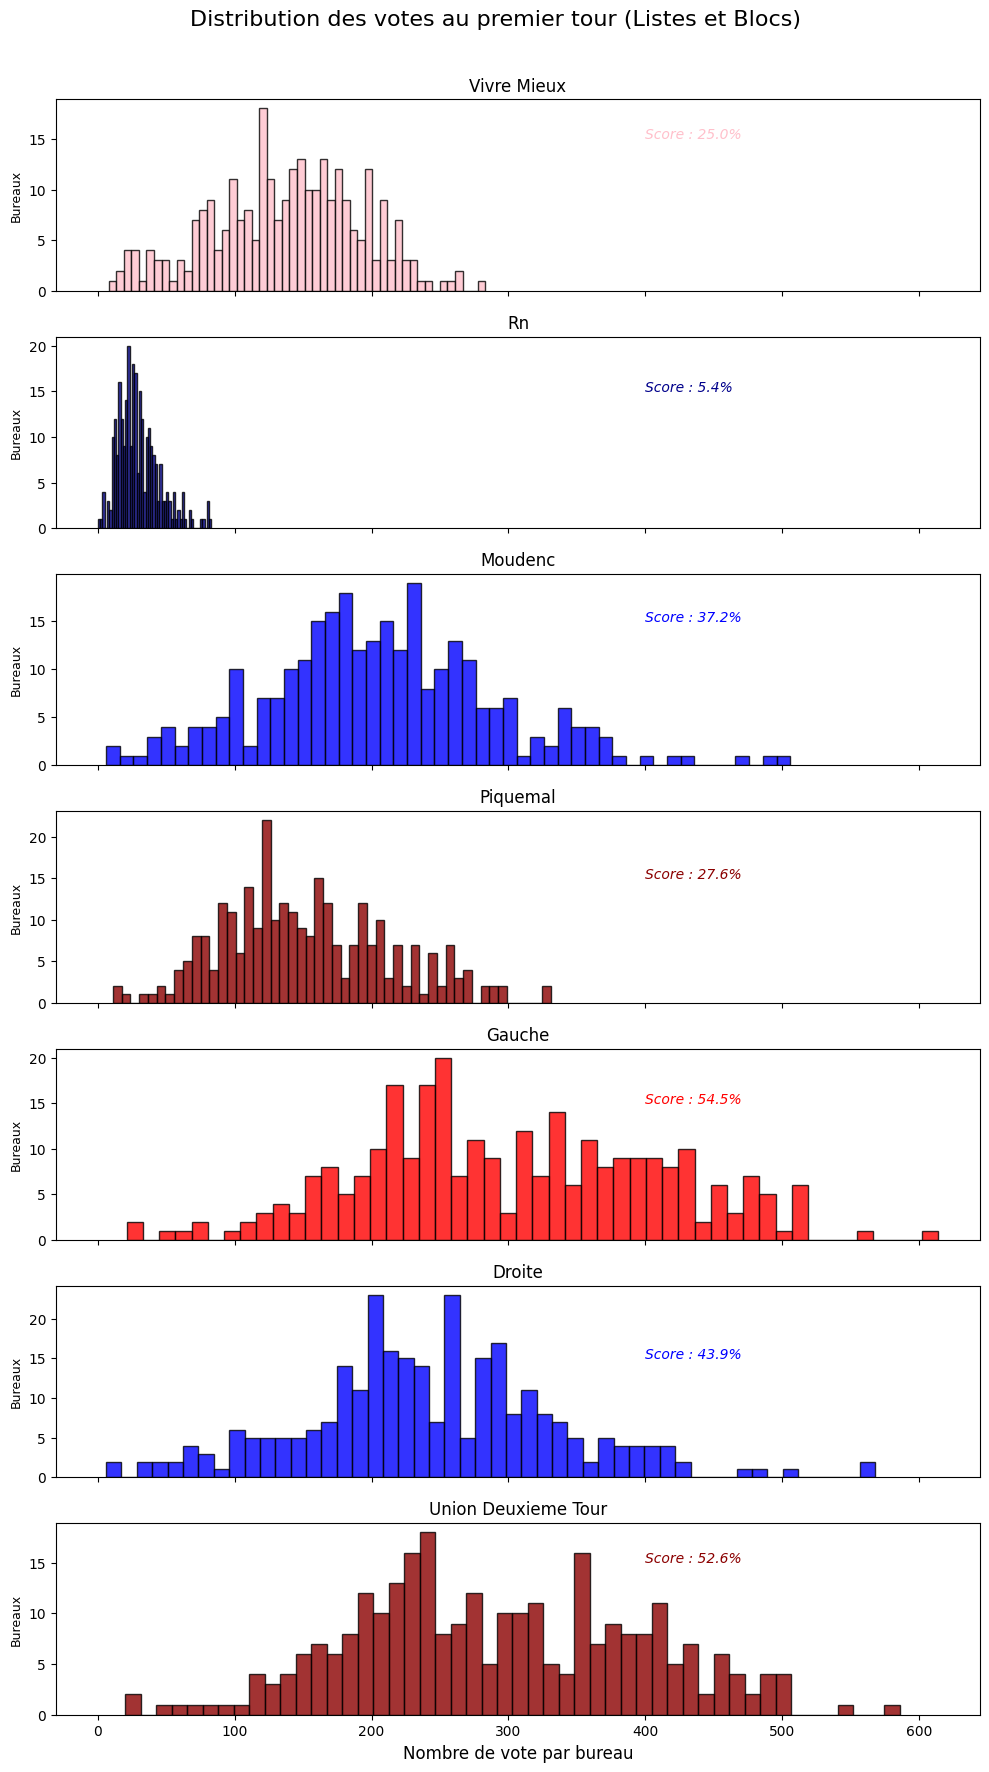

In [2]:
#| echo: false
#| warning: false
#| fig-cap: "Résultats du premier tour"
#| fig-align: "center"
#| label: fig-resultats_premier_tour
#| fig-pos: "H"

import matplotlib.pyplot as plt


scores_premier_tour = {'scores_vivre_mieux' : df['Briançon_Voix_premier_tour'], 
                       'scores_RN' : df['Leonardelli_Voix_premier_tour'],
                        'scores_Moudenc' : df['Moudenc_Voix_premier_tour'], 'scores_Piquemal' : df['Piquemal_Voix_premier_tour'], 
                        'scores_gauche' : df['scores_gauche_Voix_premier_tour'], 'scores_droite' : df['scores_droite_Voix_premier_tour'], 'scores_union_deuxieme_tour' : df['scores_union_Voix_premier_tour']
}

n_graphs = len(scores_premier_tour.items())

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

colors = ['pink', 'darkblue', 'blue', 'darkred', 'red', 'blue', 'darkred']

for ax, (nom_variable, donnees), color in zip(axes, scores_premier_tour.items(), colors):
    
    pourc_bureau = 100 * donnees / df['exprimes_premier_tour']

    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8, facecolor = color)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    score = 100*(donnees.sum()) / df['exprimes_premier_tour'].sum()
   
    texte_info = f"Score : {score:.1f}%"
    
    ax.text(x=400, y=15, s=texte_info, 
            fontsize=10, 
            color=color,
            style='italic') 
    

axes[-1].set_xlabel('Nombre de vote par bureau', fontsize=12)

fig.suptitle('Distribution des votes au premier tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/scores_Voix_listes_premier_tour.png', transparent=True)

plt.show()

## Analyse du Second tour

Pour le second tour on peut remarquer sur la figure @fig-resultats_second_tour que ce n'est pas le vote moyen qui est en la faveur de Moudenc, les courbes sont relativement les mêmes (elles suivent une loi normale centrée vers 50%). Cependant, on voit qu'il y a plus de bureaux avec un score > 55% pour Moudenc, une sorte de plafond qui empêche la liste de l'union de la gauche de monter plus haut ou un socle basale pour la liste de Moudenc.

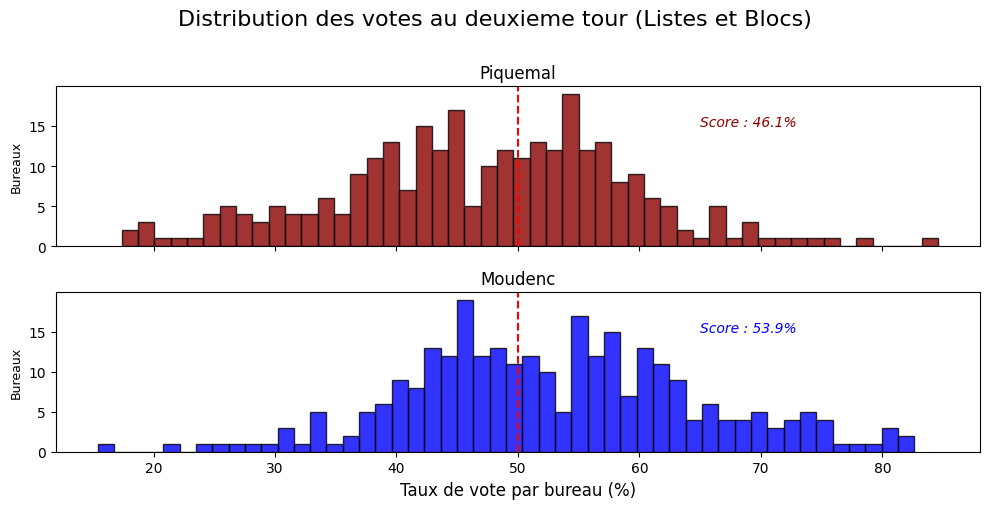

In [3]:
#| echo: false
#| warning: false
#| fig-cap: "Résultats du second tour"
#| fig-align: "center"
#| label: fig-resultats_second_tour
#| fig-pos: "H"



scores_deuxieme_tour = {'scores_Piquemal' : df['Piquemal_Voix_second_tour'],
                        'scores_Moudenc' : df['Moudenc_Voix_second_tour']}


n_graphs = len(scores_deuxieme_tour)

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

colors = ['darkred', 'blue']

for ax, (nom_variable, donnees), color in zip(axes, scores_deuxieme_tour.items(), colors):
    
    pourc_bureau = 100 * donnees / df['exprimes_second_tour']

    ax.hist(pourc_bureau, bins=50, edgecolor='black', alpha=0.8, facecolor = color)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    score = 100*(donnees.sum()) / df['exprimes_second_tour'].sum()
   
    texte_info = f"Score : {score:.1f}%"
    
    ax.text(x=65, y=15, s=texte_info, 
            fontsize=10, 
            color=color,
            style='italic') 
    
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50%')

axes[-1].set_xlabel('Taux de vote par bureau (%)', fontsize=12)

fig.suptitle('Distribution des votes au deuxieme tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/scores_listes_second_tour.png', transparent=True)

plt.show()

## Analyse des taux d'abstentions et votes blanc/nuls au premier et second tour

Une problématique importante des élections municipales se retrouve dans les taux d'abstentions. On peut voir sur la figure @fig-abstention, que 56.5% des inscrits ont voté au premier tour et 62.6% au second tour. Sans surprise, le taux de participation n'est pas le même dans tous les bureaux de votes avec de nombreux bureaux ayant moins de 50% de taux de participation mais on peut observer par contraste que de nombreux bureaux ont un taux de participation supérieur à 60% au premier, 70% au second et jusqu'à presque 80%. Celà témoigne d'une mobilisation importante de certains bureaux que l'on identifiera plus tard.

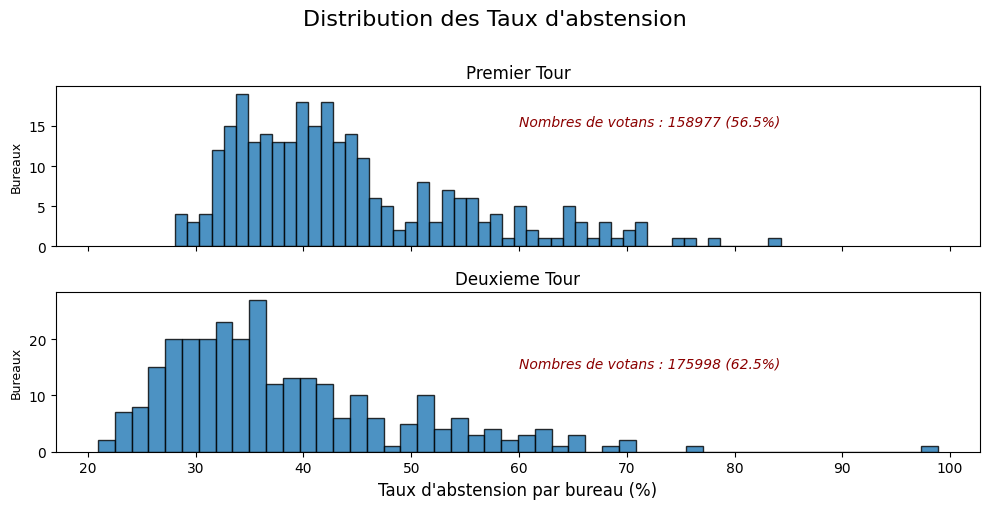

In [4]:
#| echo: false
#| warning: false
#| fig-cap: "Taux de participation dans les différents bureaux de votes"
#| fig-align: "center"
#| label: fig-abstention
#| fig-pos: "H"


participation = [[df['abstentions_premier_tour'].sum(), df['inscrits_premier_tour'].sum()], [df['abstentions_second_tour'].sum(), df['inscrits_second_tour'].sum()]]


fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 2.5 * 2), sharex=True)

for ax, (nom_variable, donnees), partic in zip(axes, {'premier_tour' : df['abstentions_premier_tour_%'], 
                                              'deuxieme_tour' : df['abstentions_second_tour_%']}.items(), participation):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    texte_info = f"Nombres de votans : {partic[1] - partic[0]:.0f} ({100 - (100 * partic[0] / partic[1]):.1f}%)"
    
    ax.text(x=60, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 

    
    
axes[-1].set_xlabel("Taux d'abstension par bureau (%)", fontsize=12)

fig.suptitle("Distribution des Taux d'abstension", fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/Taux_participation_premier_tour.png', transparent=True)

plt.show()

Une autre métrique est à prendre en comte : le vote blanc et le vote nuls. On peut voir sur la figure @fig-blc_nuls que le nombre de vote blancs/nuls au premier tour ne dépasse pas les 2000 avec une majorité de bureau autour des 5 blancs/nuls. Au second tour par contre, le nombre de vote blanc et nuls est bien plus important avec presque 5000 voix. Cette augmentation ne peut être expliquée par le taux de participation plus important au second tour (+ 10% d'augmentation de la participation et +150% d'augmentation du vote blanc/nuls).  

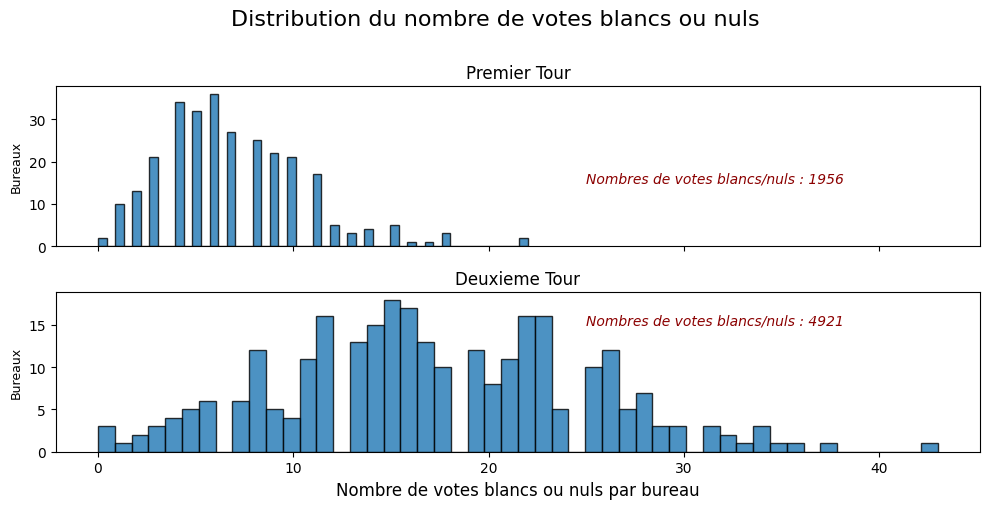

In [5]:
#| echo: false
#| warning: false
#| fig-cap: "Nombre de votes blancs / nuls dans les différents bureaux de votes"
#| fig-align: "center"
#| label: fig-blc_nuls
#| fig-pos: "H"

blc_nuls = [df['blc_nuls_Voix_premier_tour'].sum(), df['blc_nuls_Voix_second_tour'].sum()]


fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 2.5 * 2), sharex=True)

for ax, (nom_variable, donnees), votes_blancs in zip(axes, {'premier_tour' : df['blc_nuls_Voix_premier_tour'], 
                                              'deuxieme_tour' : df['blc_nuls_Voix_second_tour']}.items(), blc_nuls):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)
    
    texte_info = f"Nombres de votes blancs/nuls : {votes_blancs:.0f}"
    
    ax.text(x=25, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 
    
axes[-1].set_xlabel('Nombre de votes blancs ou nuls par bureau', fontsize=12)

fig.suptitle('Distribution du nombre de votes blancs ou nuls', fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('../plots/Votes_blancs_nuls_premier_tour.png', transparent=True)

plt.show()

# Analyse de la Typologie des votes

Chaque bureau a donc une représentation différente de ses votes et à partir de celle-ci, il est possible d'étudier leur typologie. 

In [6]:
display(df)

,bureau_premier_tour,inscrits_premier_tour,abstentions_premier_tour,votants_premier_tour,exprimes_premier_tour,Briançon_Voix_premier_tour,Scalli_Voix_premier_tour,Adrada_Voix_premier_tour,Menendez_Voix_premier_tour,Moudenc_Voix_premier_tour,...,Gaël_Coste_Meunier_Voix_europeennes_%,Jean_Marc_Governatori_Voix_europeennes_%,Hadama_Traoré_Voix_europeennes_%,Laure_Patas_d_Illiers_Voix_europeennes_%,Patrice_Grudé_Voix_europeennes_%,vivre_mieux_europeennes_%,union_gauche_europeennes_%,abstentions_premier_tour_%,abstentions_second_tour_%,abstentions_europeennes_%
0,0001,1056.0,440.0,616.0,612.0,128.0,1.0,1.0,2.0,278.0,...,0.0,1.195219,0.0,0.000000,0.0,33.266932,51.593625,41.666667,35.099338,45.513514
1,0002,901.0,337.0,564.0,558.0,150.0,1.0,3.0,0.0,216.0,...,0.0,1.422764,0.0,0.000000,0.0,36.991870,52.032520,37.402886,29.300777,40.407674
2,0003,797.0,290.0,507.0,503.0,121.0,1.0,3.0,0.0,169.0,...,0.0,0.657895,0.0,0.000000,0.0,33.333333,57.675439,36.386449,32.581454,40.077821
3,0004,882.0,355.0,527.0,524.0,155.0,1.0,1.0,0.0,174.0,...,0.0,0.211864,0.0,0.000000,0.0,39.194915,58.898305,40.249433,33.673469,42.632850
4,0005,957.0,401.0,556.0,550.0,121.0,0.0,1.0,3.0,185.0,...,0.0,2.155172,0.0,0.000000,0.0,26.724138,51.724138,41.901776,35.041841,42.735043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,239A,1076.0,489.0,587.0,580.0,145.0,1.0,2.0,1.0,229.0,...,0.0,2.333932,0.0,0.179533,0.0,30.700180,48.833034,45.446097,38.754647,41.753653
282,240A,735.0,402.0,333.0,330.0,69.0,0.0,4.0,2.0,123.0,...,0.0,1.459854,0.0,0.000000,0.0,22.262774,46.350365,54.693878,50.884354,54.664484
283,242A,936.0,474.0,462.0,458.0,112.0,1.0,1.0,4.0,148.0,...,0.0,3.367876,0.0,0.000000,0.0,30.829016,54.404145,50.641026,47.008547,52.375152
284,243A,888.0,573.0,315.0,313.0,71.0,1.0,5.0,3.0,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.527027,59.797297,NaN


In [7]:
#| echo: false
#| warning: false
#| output: false
#| include: false

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X = df.drop(columns=df.filter(regex='score').columns).filter(like='premier_tour').filter(regex='_%|bureau')
X = X.dropna()

bureau_X = X['bureau_premier_tour']
X = X.drop(columns=['bureau_premier_tour'])

display(X)


,blc_nuls_Voix_premier_tour_%,Briançon_Voix_premier_tour_%,Scalli_Voix_premier_tour_%,Adrada_Voix_premier_tour_%,Menendez_Voix_premier_tour_%,Moudenc_Voix_premier_tour_%,Leonardelli_Voix_premier_tour_%,Cottrel_Voix_premier_tour_%,Meilhac_Voix_premier_tour_%,Piquemal_Voix_premier_tour_%,Pedinotti_Voix_premier_tour_%,abstentions_premier_tour_%
0,0.653595,20.915033,0.163399,0.163399,0.326797,45.424837,2.124183,1.143791,0.326797,27.777778,1.633987,41.666667
1,1.075269,26.881720,0.179211,0.537634,0.000000,38.709677,3.225806,0.358423,0.716846,28.673835,0.716846,37.402886
2,0.795229,24.055666,0.198807,0.596421,0.000000,33.598410,3.777336,0.795229,2.186879,32.803181,1.988072,36.386449
3,0.572519,29.580153,0.190840,0.190840,0.000000,33.206107,2.671756,0.381679,1.908397,30.343511,1.526718,40.249433
4,1.090909,22.000000,0.000000,0.181818,0.545455,33.636364,2.363636,0.545455,1.636364,37.818182,1.272727,41.901776
...,...,...,...,...,...,...,...,...,...,...,...,...
280,1.061008,21.485411,0.265252,0.265252,0.000000,43.766578,9.549072,0.265252,2.122016,20.689655,1.591512,50.130890
281,1.206897,25.000000,0.172414,0.344828,0.172414,39.482759,6.379310,2.068966,3.275862,22.586207,0.517241,45.446097
282,0.909091,20.909091,0.000000,1.212121,0.606061,37.272727,11.818182,0.606061,2.424242,23.939394,1.212121,54.693878
283,0.873362,24.454148,0.218341,0.218341,0.873362,32.314410,5.458515,0.000000,1.091703,34.497817,0.873362,50.641026


In [8]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

In [9]:
#| echo: false
#| warning: false
#| output: false
#| include: false


colonnes_totales = X.columns

df_loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=colonnes_totales  
)

print("--- Contributions à l'axe PC1 ---")
display(df_loadings.sort_values(by='PC1', ascending=False)['PC1'])

print("\n--- Contributions à l'axe PC2 ---")
display(df_loadings.sort_values(by='PC2', ascending=False)['PC2'])

--- Contributions à l'axe PC1 ---


Piquemal_Voix_premier_tour_%       0.444143
abstentions_premier_tour_%         0.439833
Menendez_Voix_premier_tour_%       0.336496
Adrada_Voix_premier_tour_%         0.257290
Pedinotti_Voix_premier_tour_%      0.242176
blc_nuls_Voix_premier_tour_%       0.223173
Scalli_Voix_premier_tour_%         0.211443
Leonardelli_Voix_premier_tour_%    0.077858
Briançon_Voix_premier_tour_%      -0.160434
Meilhac_Voix_premier_tour_%       -0.195706
Cottrel_Voix_premier_tour_%       -0.196360
Moudenc_Voix_premier_tour_%       -0.409919
Name: PC1, dtype: float64


--- Contributions à l'axe PC2 ---


Briançon_Voix_premier_tour_%       0.491834
Piquemal_Voix_premier_tour_%       0.268340
Pedinotti_Voix_premier_tour_%      0.197794
Meilhac_Voix_premier_tour_%        0.086178
Adrada_Voix_premier_tour_%        -0.060161
Scalli_Voix_premier_tour_%        -0.076565
Menendez_Voix_premier_tour_%      -0.142457
blc_nuls_Voix_premier_tour_%      -0.210296
abstentions_premier_tour_%        -0.291649
Moudenc_Voix_premier_tour_%       -0.359688
Cottrel_Voix_premier_tour_%       -0.367840
Leonardelli_Voix_premier_tour_%   -0.464547
Name: PC2, dtype: float64

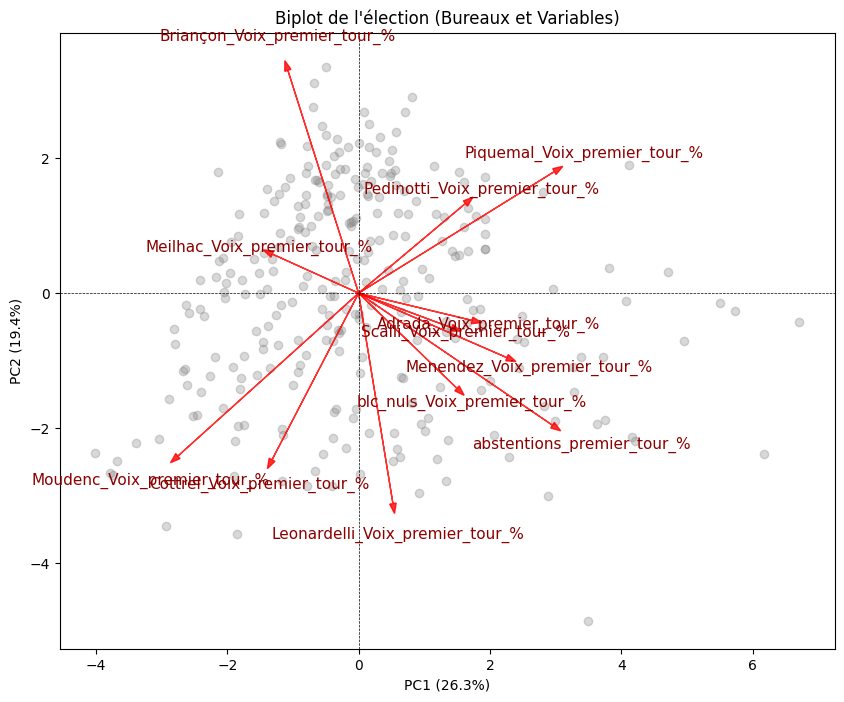

In [10]:
#| echo: false
#| warning: false
#| fig-cap: "Représentation 2D des variables au premier tour"
#| fig-align: "center"
#| output: false
#| include: false

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')
plt.savefig('../plots/Biplot_premier_tour.png', transparent=True)

plt.show()

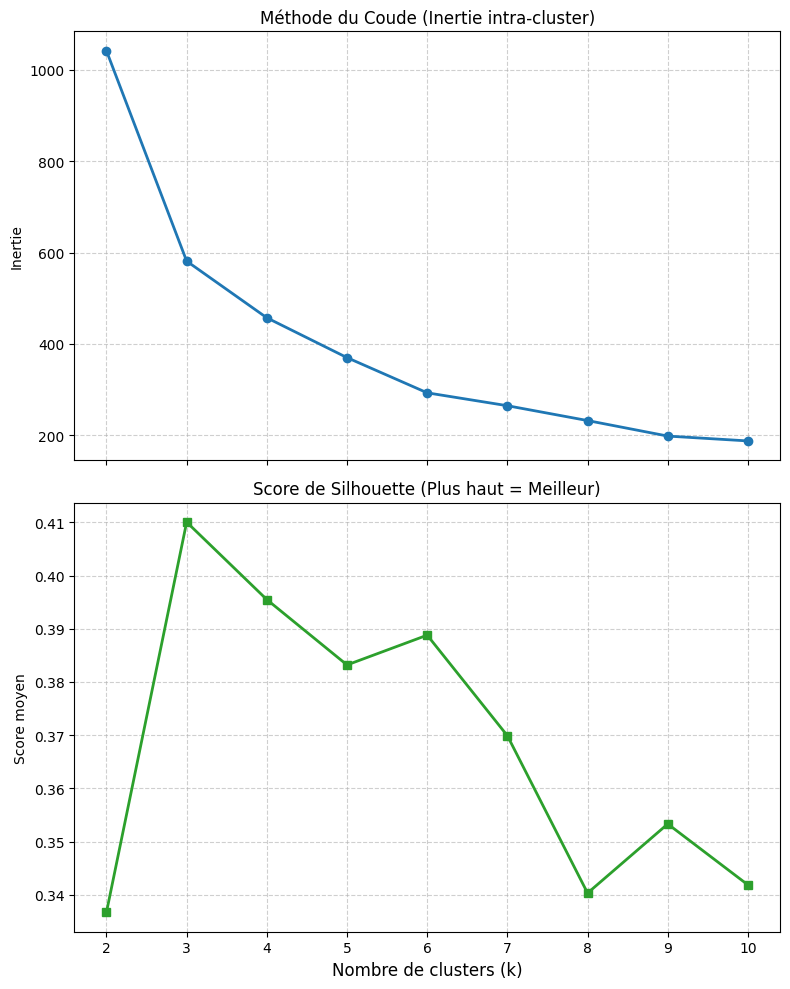

In [11]:
#| echo: false
#| warning: false
#| output: false
#| include: false

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Afin de catégoriser les bureaux ayant des profils similaire, un algorithme de clustering K-means a été utilisé sur les résultats du premier tour. Le nombre K de cluster pour cette première analyse a été choisié à partir l'analyse de courbe intertie et de score Silhouette sur K entre 2 et 10. On a donc 3 clusters 0, 1 et 2 composés respectivement de 68, 130 et 86 bureaux de vote. 

In [12]:
#| echo: false
#| warning: false

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

X['Cluster_premier_tour'] = labels_clusters.astype(str)
X['bureau_premier_tour'] = bureau_X
print("Nombre de bureaux par cluster :")
print(X['Cluster_premier_tour'].value_counts())

df = pd.merge(df, X.filter(regex='bureau_premier_tour|Cluster_premier'), on='bureau_premier_tour', how='outer')


Nombre de bureaux par cluster :
Cluster_premier_tour
2    138
1     90
0     56
Name: count, dtype: int64


In [13]:
#| echo: false
#| warning: false

profils_clusters = X.drop(columns=['bureau_premier_tour']).groupby('Cluster_premier_tour').mean()

Sur la figure @fig-cluster3_premier, on peut observer les différentes tendances de ces 3 clusters. Le cluster 0 correspond à un cluster avec un taux de participation faible, le deuxième pourrait être qualifié de cluster par défaut et le troisième de droite. 

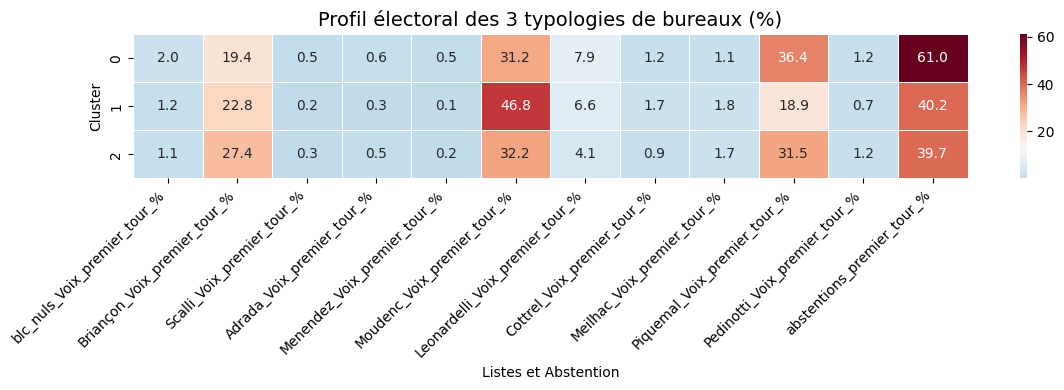

In [14]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 3 typologies de bureaux de vote au premier tour"
#| fig-align: "center"
#| label: fig-cluster3_premier
#| fig-pos: "H"

import seaborn as sns

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 3 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../plots/Clusters_premier_tour.png', transparent=True)

plt.show()

# Analyse dynamique temporelle

Une analyse dynamique temporelle a été effectuée pour déterminer les effets de report de voix entre le premier et le second tour.

In [15]:
#| echo: false
#| warning: false
#| include: false
#| output: false

X = df.drop(columns=df.filter(regex='score').columns).filter(like='_tour').filter(regex='_%|bureau')
X = X.dropna()

bureau_X = X['bureau_premier_tour']
X = X.drop(columns=['bureau_premier_tour', 'bureau_second_tour'])

display(X)

,blc_nuls_Voix_premier_tour_%,Briançon_Voix_premier_tour_%,Scalli_Voix_premier_tour_%,Adrada_Voix_premier_tour_%,Menendez_Voix_premier_tour_%,Moudenc_Voix_premier_tour_%,Leonardelli_Voix_premier_tour_%,Cottrel_Voix_premier_tour_%,Meilhac_Voix_premier_tour_%,Piquemal_Voix_premier_tour_%,Pedinotti_Voix_premier_tour_%,blc_nuls_Voix_second_tour_%,Moudenc_Voix_second_tour_%,Piquemal_Voix_second_tour_%,abstentions_premier_tour_%,abstentions_second_tour_%
0,0.653595,20.915033,0.163399,0.163399,0.326797,45.424837,2.124183,1.143791,0.326797,27.777778,1.633987,1.179941,56.784661,43.215339,41.666667,35.099338
1,1.075269,26.881720,0.179211,0.537634,0.000000,38.709677,3.225806,0.358423,0.716846,28.673835,0.716846,2.083333,55.288462,44.711538,37.402886,29.300777
2,0.795229,24.055666,0.198807,0.596421,0.000000,33.598410,3.777336,0.795229,2.186879,32.803181,1.988072,1.127820,51.691729,48.308271,36.386449,32.581454
3,0.572519,29.580153,0.190840,0.190840,0.000000,33.206107,2.671756,0.381679,1.908397,30.343511,1.526718,2.811951,50.615114,49.384886,40.249433,33.673469
4,1.090909,22.000000,0.000000,0.181818,0.545455,33.636364,2.363636,0.545455,1.636364,37.818182,1.272727,3.156146,48.504983,51.495017,41.901776,35.041841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,1.061008,21.485411,0.265252,0.265252,0.000000,43.766578,9.549072,0.265252,2.122016,20.689655,1.591512,3.286385,60.563380,39.436620,50.130890,42.483660
280,1.206897,25.000000,0.172414,0.344828,0.172414,39.482759,6.379310,2.068966,3.275862,22.586207,0.517241,2.170543,58.294574,41.705426,45.446097,38.754647
281,0.909091,20.909091,0.000000,1.212121,0.606061,37.272727,11.818182,0.606061,2.424242,23.939394,1.212121,2.266289,61.756374,38.243626,54.693878,50.884354
282,0.873362,24.454148,0.218341,0.218341,0.873362,32.314410,5.458515,0.000000,1.091703,34.497817,0.873362,2.479339,47.107438,52.892562,50.641026,47.008547


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

In [17]:
#| echo: false
#| warning: false
#| include: false
#| output: false

colonnes_totales = X.columns

df_loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=colonnes_totales  
)

print("--- Contributions à l'axe PC1 ---")
display(df_loadings.sort_values(by='PC1', ascending=False)['PC1'])

print("\n--- Contributions à l'axe PC2 ---")
display(df_loadings.sort_values(by='PC2', ascending=False)['PC2'])

--- Contributions à l'axe PC1 ---


Piquemal_Voix_second_tour_%        0.398230
Piquemal_Voix_premier_tour_%       0.397447
abstentions_second_tour_%          0.315174
abstentions_premier_tour_%         0.304594
Menendez_Voix_premier_tour_%       0.209626
Pedinotti_Voix_premier_tour_%      0.186008
Adrada_Voix_premier_tour_%         0.149848
Scalli_Voix_premier_tour_%         0.135309
blc_nuls_Voix_premier_tour_%       0.122204
Leonardelli_Voix_premier_tour_%   -0.017933
Briançon_Voix_premier_tour_%      -0.058739
blc_nuls_Voix_second_tour_%       -0.070968
Meilhac_Voix_premier_tour_%       -0.126236
Cottrel_Voix_premier_tour_%       -0.180669
Moudenc_Voix_premier_tour_%       -0.375667
Moudenc_Voix_second_tour_%        -0.398230
Name: PC1, dtype: float64


--- Contributions à l'axe PC2 ---


Briançon_Voix_premier_tour_%       0.447507
Piquemal_Voix_second_tour_%        0.209334
blc_nuls_Voix_second_tour_%        0.192517
Piquemal_Voix_premier_tour_%       0.135620
Meilhac_Voix_premier_tour_%        0.097178
Pedinotti_Voix_premier_tour_%      0.086495
Adrada_Voix_premier_tour_%        -0.100427
Scalli_Voix_premier_tour_%        -0.117974
Menendez_Voix_premier_tour_%      -0.177150
Moudenc_Voix_second_tour_%        -0.209334
Moudenc_Voix_premier_tour_%       -0.216100
blc_nuls_Voix_premier_tour_%      -0.220973
Cottrel_Voix_premier_tour_%       -0.244663
abstentions_second_tour_%         -0.349244
abstentions_premier_tour_%        -0.367994
Leonardelli_Voix_premier_tour_%   -0.414186
Name: PC2, dtype: float64

Différentes métriques ont été calculées : Delta abstention qui correpond à la différence d'abstention entre le premier et le second tour, Delta_gauche la différence entre les voix de la fusion du second tour avec la somme des voix des deux listes de gauche du premier tour.  

La figure @fig-biplot correspond à une représentation 2D des différentes variables des bureaux de vote par analyse des composantes principales (ACP). L'idée est de regarder quelle variable est proche de qu'elle autre variable. Par exemple, on voit un clair axe Piquemal - Leonardelli qui témoigne par exemple de l'oposition LFI - RN. On peut aussi observer, sans surprise que les listes NPA, Luttes Ouvrières et du Parti des travailleurs se regroupent. Les variables de Moudenc_premier et Moudenc_second sont très proches de l'axe Cottrel (Reconquete).   

Dernier point important et triste à noter : L'axe Briançon est très proche de l'axe blc_nuls_second. En d'autres termes, ce sont les mêmes personnes (avec aussi les voix de Meilhac).

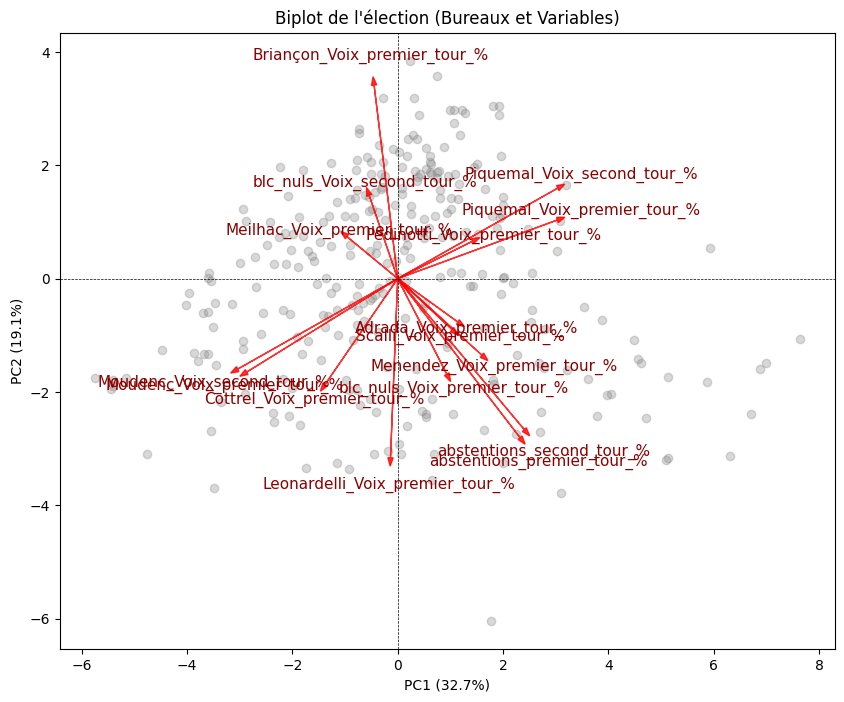

In [18]:
#| echo: false
#| warning: false
#| fig-cap: "Représentation 2D des variables au premier + second tour"
#| fig-align: "center"
#| label: fig-biplot
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')
plt.savefig('../plots/Biplot_second_tour.png', transparent=True)
plt.show()

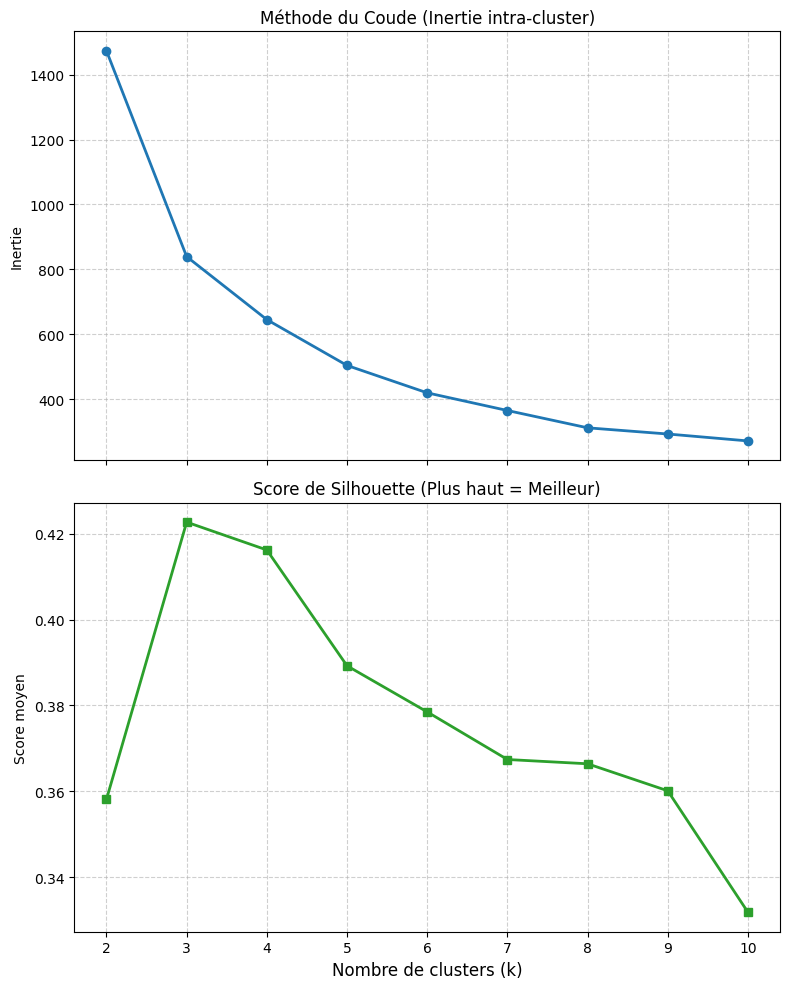

In [19]:
#| echo: false
#| warning: false
#| output: false
#| include: false

k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

D'autres clusters ont été générés sur les données du premier + second tour.

On peut voir sur la figure @fig-cluster3_fusion des profils proches des clusters du premier tour. On peut quand même identifié que le cluster de droite (2) a le delta d'abstention le plus faible. En d'autres termes, c'est celui qui a eu une diminution de l'abstention la plus forte donc une mobilisation plus importante au second tour. En gros : la peur de la FI.

In [20]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 3 typologies de bureaux de vote premier + second tour"
#| fig-align: "center"
#| label: fig-cluster3_fusion
#| fig-pos: "H"

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

X['Cluster_municipales'] = labels_clusters.astype(str)
X['bureau_premier_tour'] = bureau_X
print("Nombre de bureaux par cluster :")
print(X['Cluster_municipales'].value_counts())

df = pd.merge(df, X.filter(regex='bureau_premier_tour|Cluster_municipales'), on='bureau_premier_tour', how='outer')

profils_clusters = X.drop(columns=['bureau_premier_tour']).groupby('Cluster_municipales').mean()

Nombre de bureaux par cluster :
Cluster_municipales
1    133
0    110
2     41
Name: count, dtype: int64


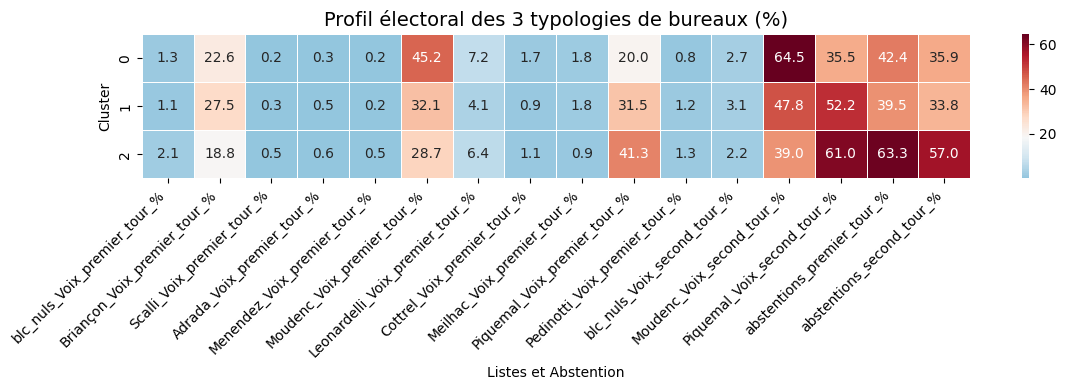

In [21]:
plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 3 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/Cluster_3_municipales.png', transparent=True)

plt.show()

Un deuxième clustering a été effectué car il pourrait décrire des poches électorales très spécifiques et cohérentes. La figure @fig-cluster8_fusion montre ces 8 clusters avec leur score respectifs. Une représentation géographique est présentée plus tard et pourrait expliquée ce clustering. Cependant, mon absence de connaissances assez importante sur les quartiers de Toulouse ne me permet pas de faire d'analyses poussées.

In [22]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 8 typologies de bureaux de vote premier + second tour"
#| fig-align: "center"
#| label: fig-cluster8_fusion
#| fig-pos: "H"

kmeans_final = KMeans(n_clusters=8, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

X['Cluster_8_municipales'] = labels_clusters.astype(str)
print("Nombre de bureaux par cluster :")
print(X['Cluster_8_municipales'].value_counts())

df = pd.merge(df, X.filter(regex='bureau_premier_tour|Cluster_8_municipales'), on='bureau_premier_tour', how='outer')

profils_clusters = X.drop(columns=['bureau_premier_tour', 'Cluster_municipales']).groupby('Cluster_8_municipales').mean()

Nombre de bureaux par cluster :
Cluster_8_municipales
2    79
6    61
0    38
4    33
1    31
7    19
3    14
5     9
Name: count, dtype: int64


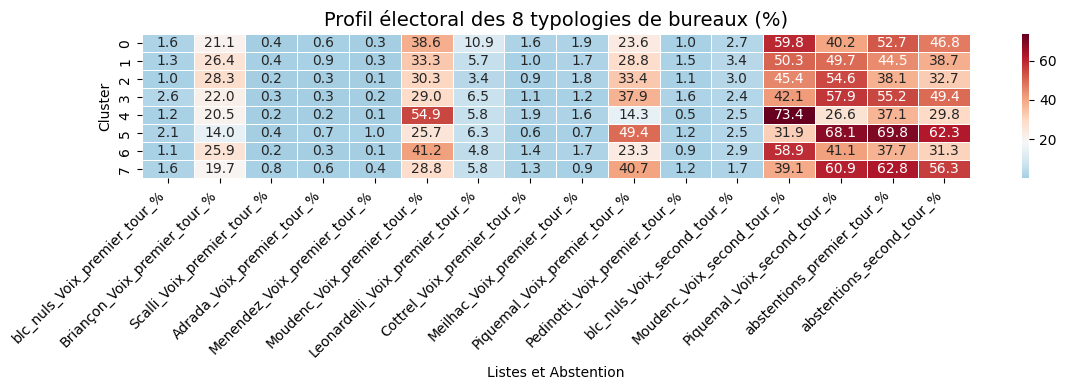

In [23]:
plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 8 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/Clusters_8_municipales.png', transparent=True)

plt.show()

# Analyse Spatiale des résultats

Maintenant, passons aux cartes !

Sur la figure @fig-map_cluster3_premier on peut observer les 3 clusters du premier tour avec on le rappelle : cluster 0 = abstention, cluster 1 par défaut et cluster 2 de droite.

In [24]:
lieux_de_vote = gpd.read_file("../data/raw/election-2026-lieux-de-vote.geojson")
lieux_de_vote['bureau'] = lieux_de_vote['bureau'].astype(str).str.zfill(4)

final_data = pd.merge(lieux_de_vote, df, left_on = 'bureau', right_on='bureau_premier_tour', how='outer')

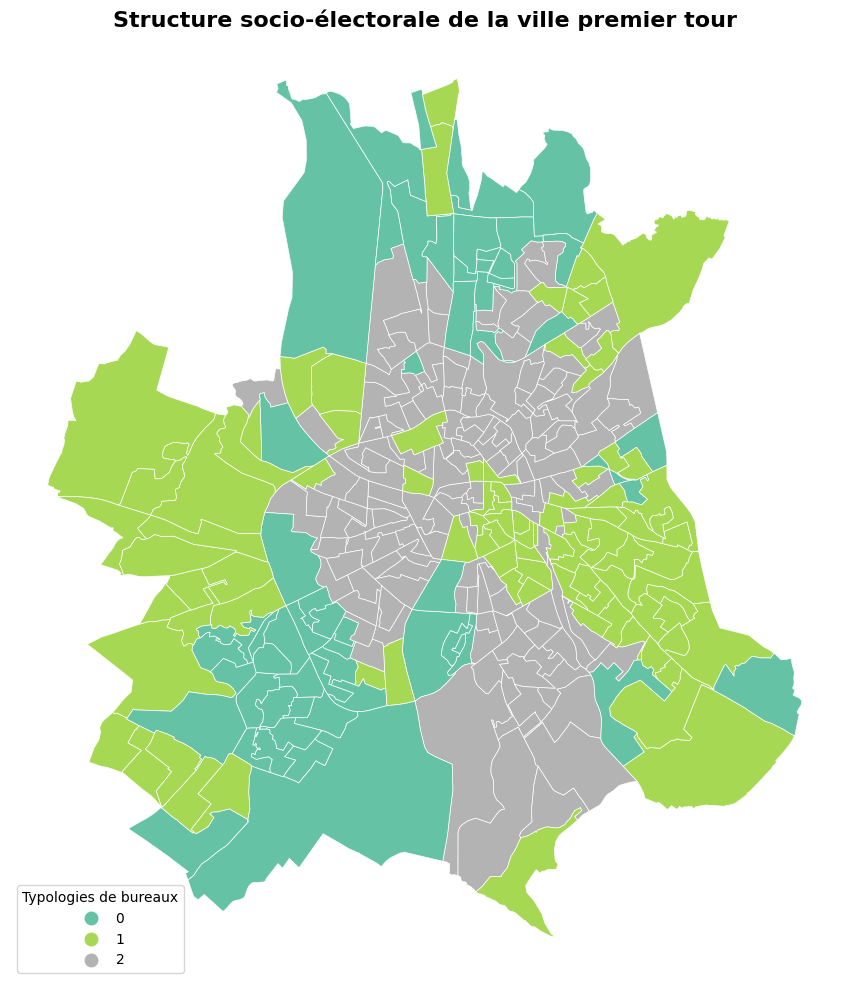

In [25]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 3 typologies de bureaux de vote premier"
#| fig-align: "center"
#| label: fig-map_cluster3_premier
#| fig-pos: "H"

import geopandas as gpd

fig, ax = plt.subplots(figsize=(12, 10))


final_data.plot(
    column='Cluster_premier_tour', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    linewidth=0.5,
    edgecolor='white', 
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville premier tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Clusters_map_premier_tour.png', transparent=True)

plt.show()

Sur la figure @fig-map_cluster3_fusion, on observe la même répartition des clusters. 

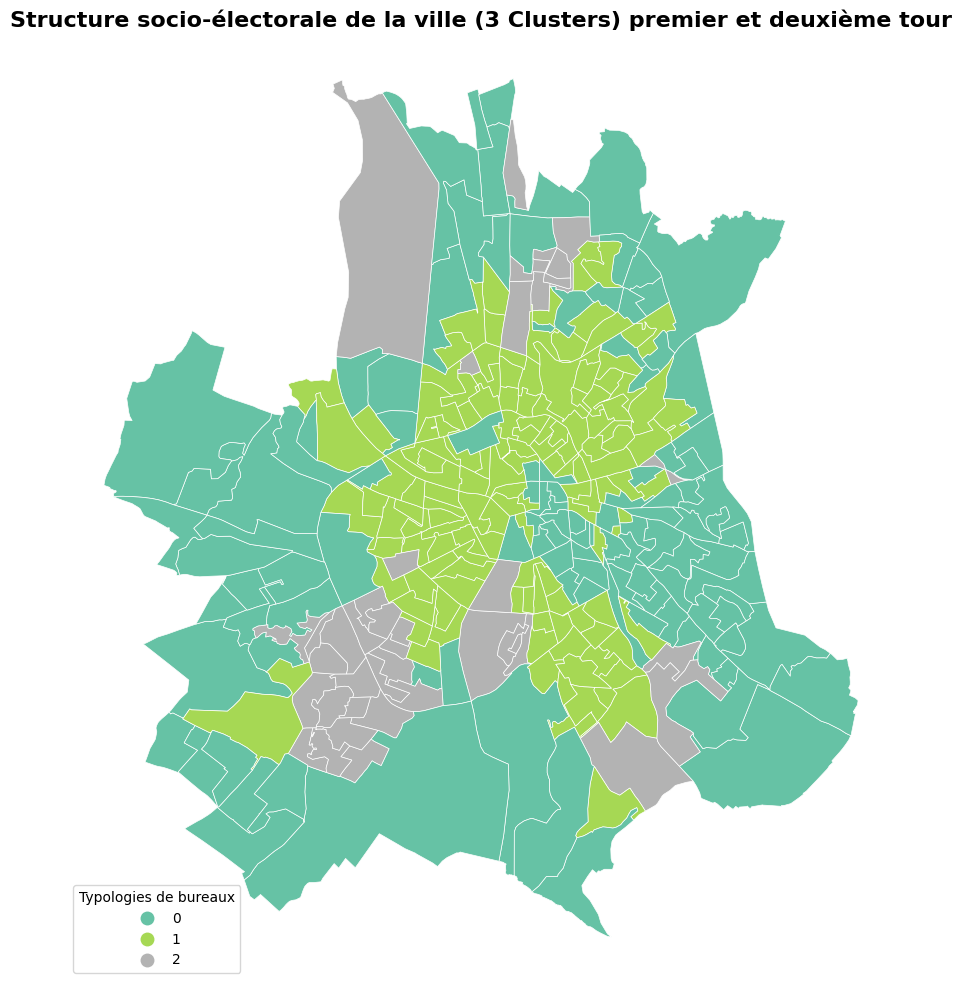

In [26]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 3 typologies de bureaux de vote premier + second tour"
#| fig-align: "center"
#| label: fig-map_cluster3_fusion
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Cluster_municipales', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    edgecolor='white', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville (3 Clusters) premier et deuxième tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Clusters_3_joined_map.png', transparent=True)
plt.show()

Sur la figure @fig-map_cluster8_fusion on peut observer les 8 différents clusters présentés précédemment. Un expert de la géographie de Toulouse pourrait identifier des quartiers spécifiques et pourrait associé ça à leur score présenté sur la figure @fig-cluster8_fusion

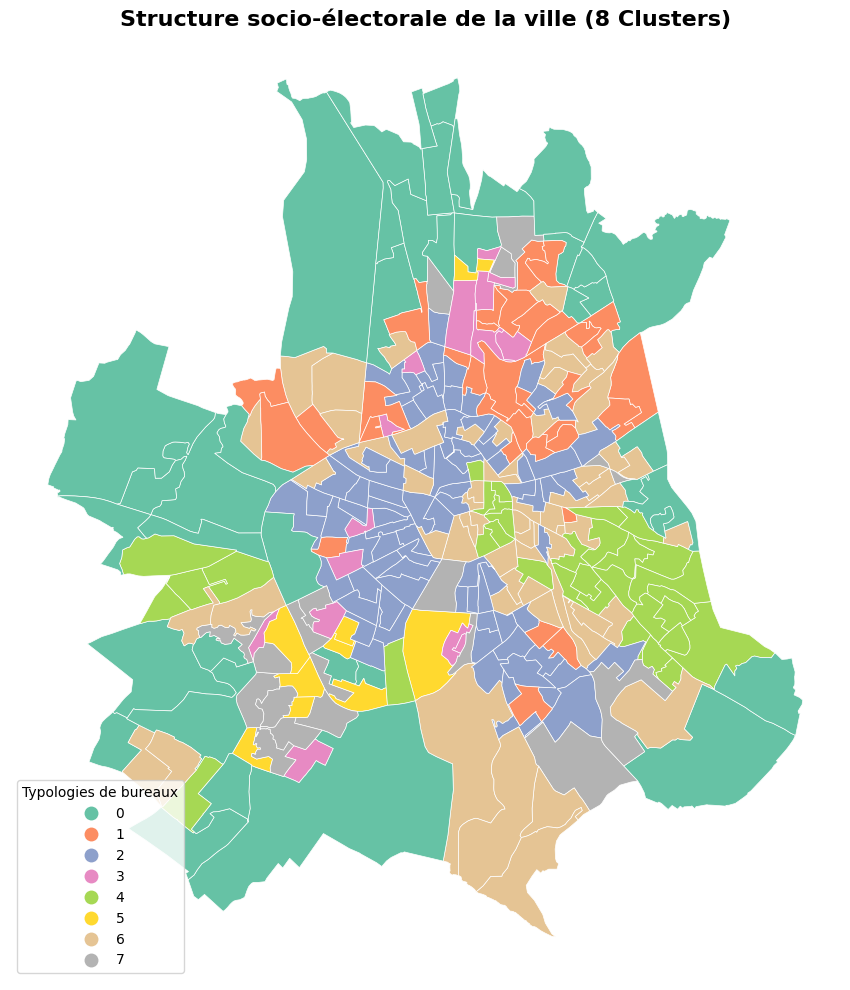

In [27]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 8 typologies de bureaux de vote premier + second tour"
#| fig-align: "center"
#| label: fig-map_cluster8_fusion
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Cluster_8_municipales', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    edgecolor='white', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville (8 Clusters)", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Clusters_8_map.png', transparent=True)
plt.show()

L'indice de Morgan sur l'abstention au premier tour détermine le fait que l'abstention est relativement localisée dans des bureaux proches. Ce qu'on peut voir visuellement avec la figure @fig-map_abstension_premier.

Sans surprise, le centre a particulièrement voté et l'abstention est très localisée sur quelques quartiers.

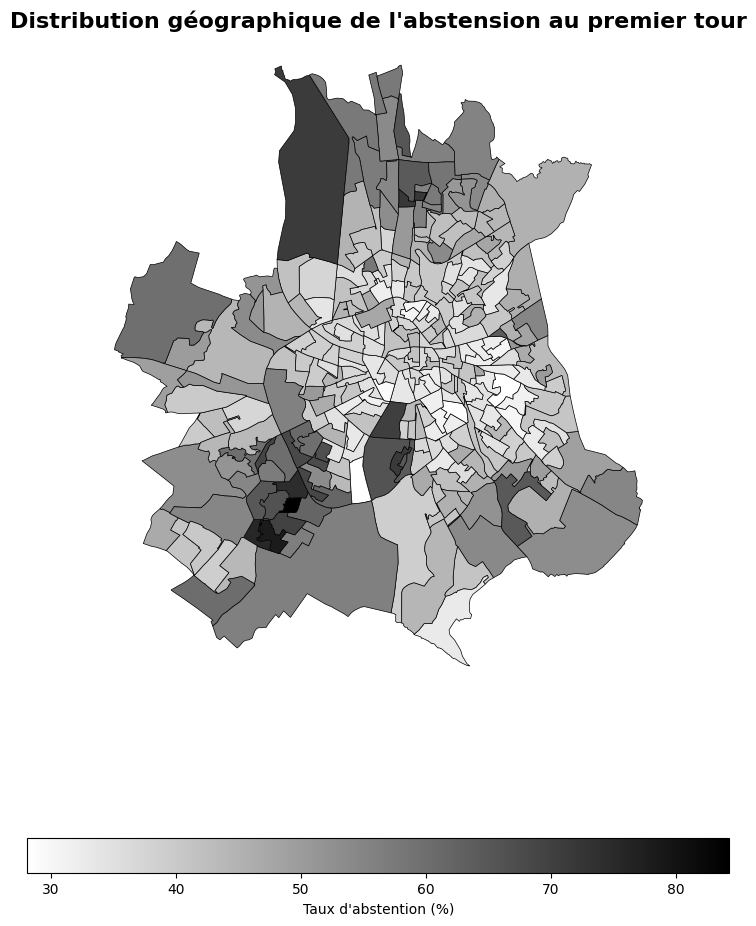

In [28]:
#| echo: false
#| warning: false
#| fig-cap: "Taux d'absention au premier tour"
#| fig-align: "center"
#| label: fig-map_abstension_premier
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='abstentions_premier_tour_%', 
    categorical=False, 
    legend=True, 
    cmap='binary', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux d'abstention (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique de l'abstension au premier tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Abstentions_map_premier_tour.png', transparent=True)

plt.show()

Pour la représentation des résultats des différentes listes, on a sur la figure @fig-map_vivre_mieux les scores de la liste vivre mieux. Interprétations libres

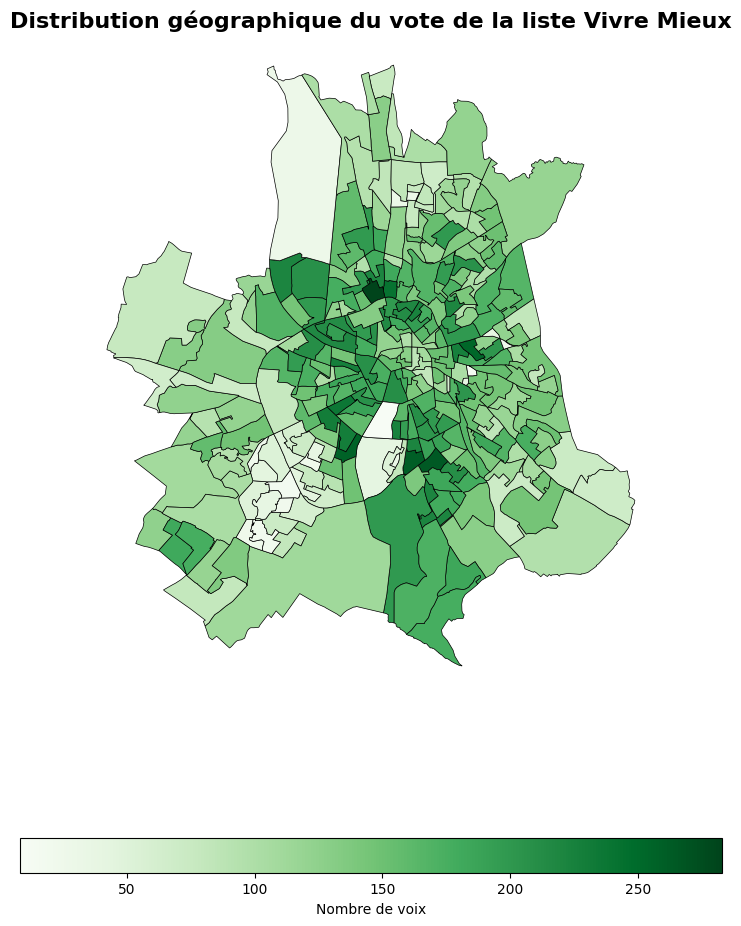

In [29]:
#| echo: false
#| warning: false
#| fig-cap: "Résultats de la liste Vivre mieux au premier Tour"
#| fig-align: "center"
#| label: fig-map_vivre_mieux
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Briançon_Voix_premier_tour', 
    categorical=False, 
    legend=True, 
    cmap='Greens', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Vivre Mieux", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Vivre_mieux_Voix_map_premier_tour.png', transparent=True)

plt.show()

Les scores de la liste de Moudenc sur la figure @fig-map_Moudenc_premier.

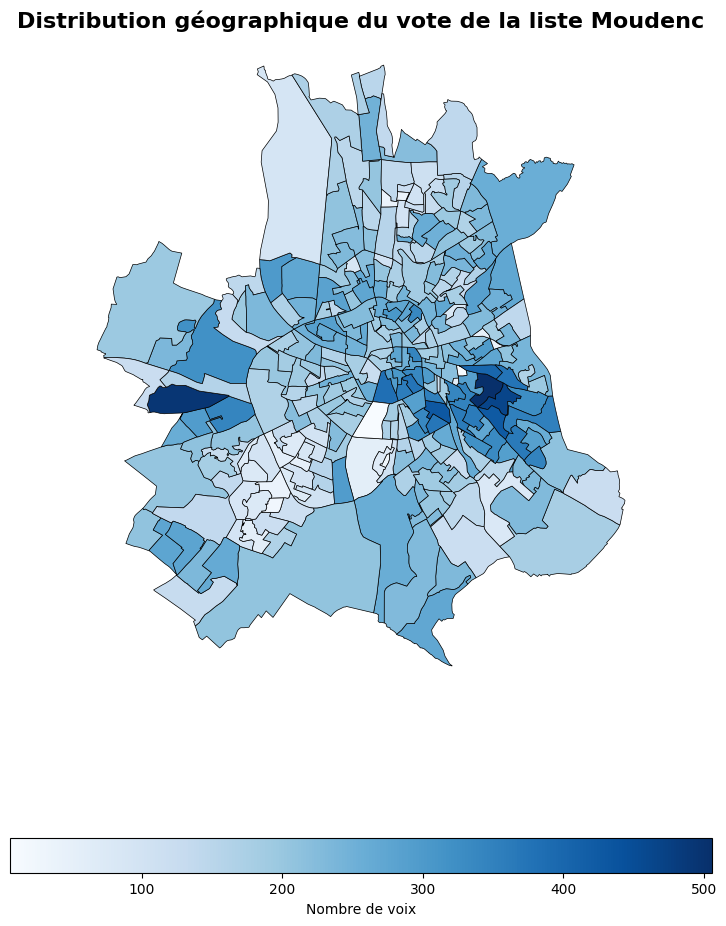

In [30]:
#| echo: false
#| warning: false
#| fig-cap: "Résultat de la liste de Moudenc au premier tour"
#| fig-align: "center"
#| label: fig-map_Moudenc_premier
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Moudenc_Voix_premier_tour', 
    categorical=False, 
    legend=True, 
    cmap='Blues', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Moudenc", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Moudenc_Voix_map_premier_tour.png', transparent=True)

plt.show()

Et les scores de la liste de Piquemal au premier Tour sur la figure @fig-map_Piquemal_premier

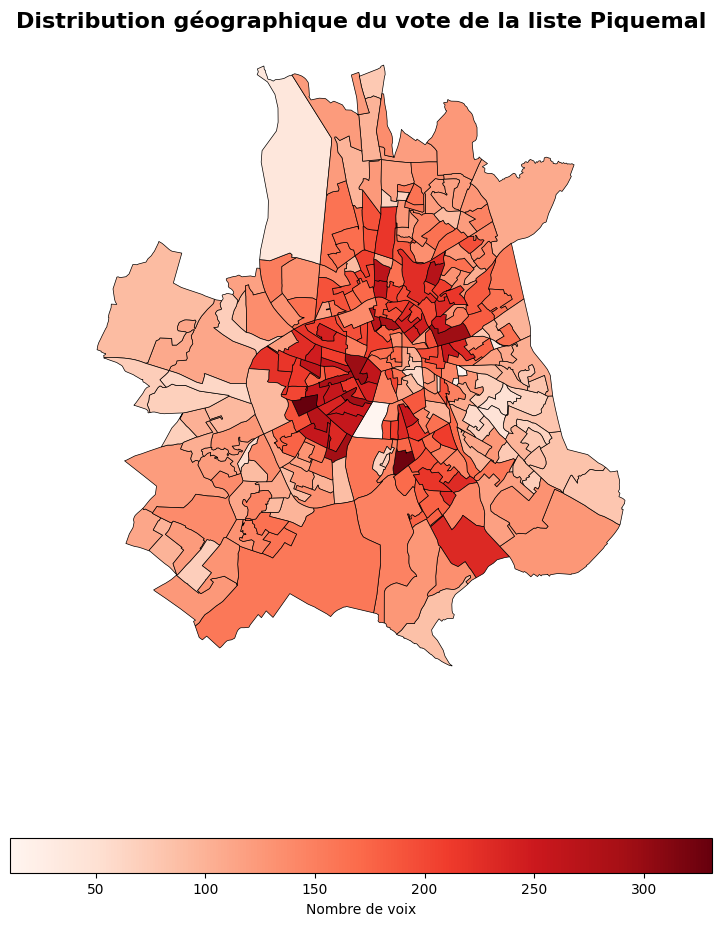

In [31]:
#| echo: false
#| warning: false
#| fig-cap: "Résultat de la liste de Piquemal au premier tour"
#| fig-align: "center"
#| label: fig-map_Piquemal_premier
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Piquemal_Voix_premier_tour', 
    categorical=False, 
    legend=True, 
    cmap='Reds', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Piquemal", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Piquemal_Voix_map_premier_tour.png', transparent=True)

plt.show()

L'abstention au second tour sur la figure @fig-map_abstension_second

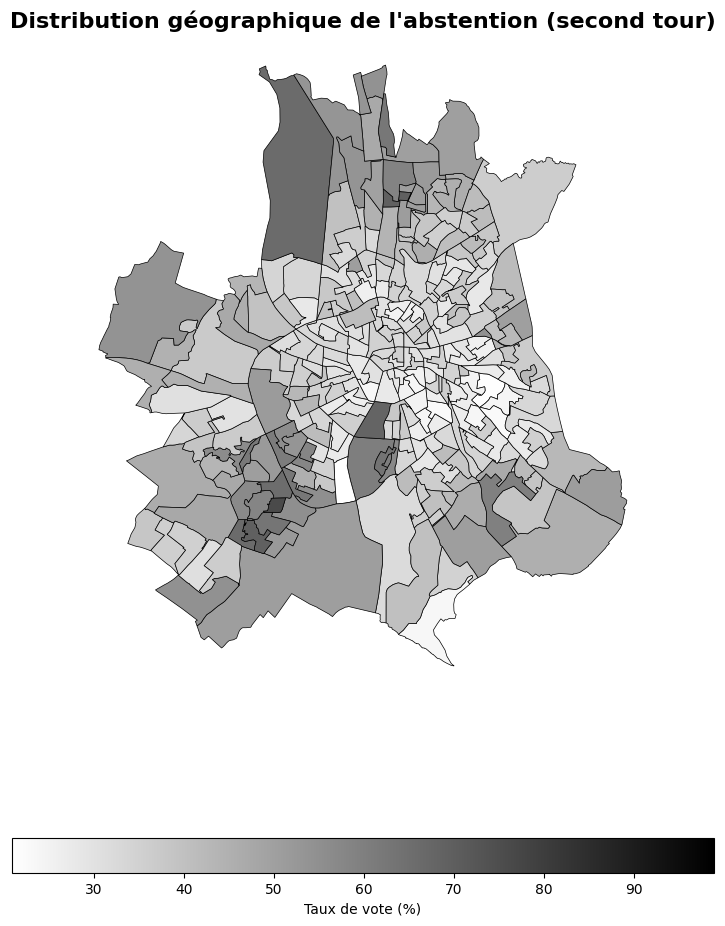

In [32]:
#| echo: false
#| warning: false
#| fig-cap: "Taux d'abstension au second tour"
#| fig-align: "center"
#| label: fig-map_abstension_second
#| fig-pos: "H"


fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='abstentions_second_tour_%', 
    categorical=False, 
    legend=True, 
    cmap='binary', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Taux de vote (%)", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique de l'abstention (second tour)", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Abstentions_map_deuxieme_tour.png', transparent=True)

plt.show()

Les scores de la liste de Moudenc au second tour sur la figure @fig-map_Moudenc_second

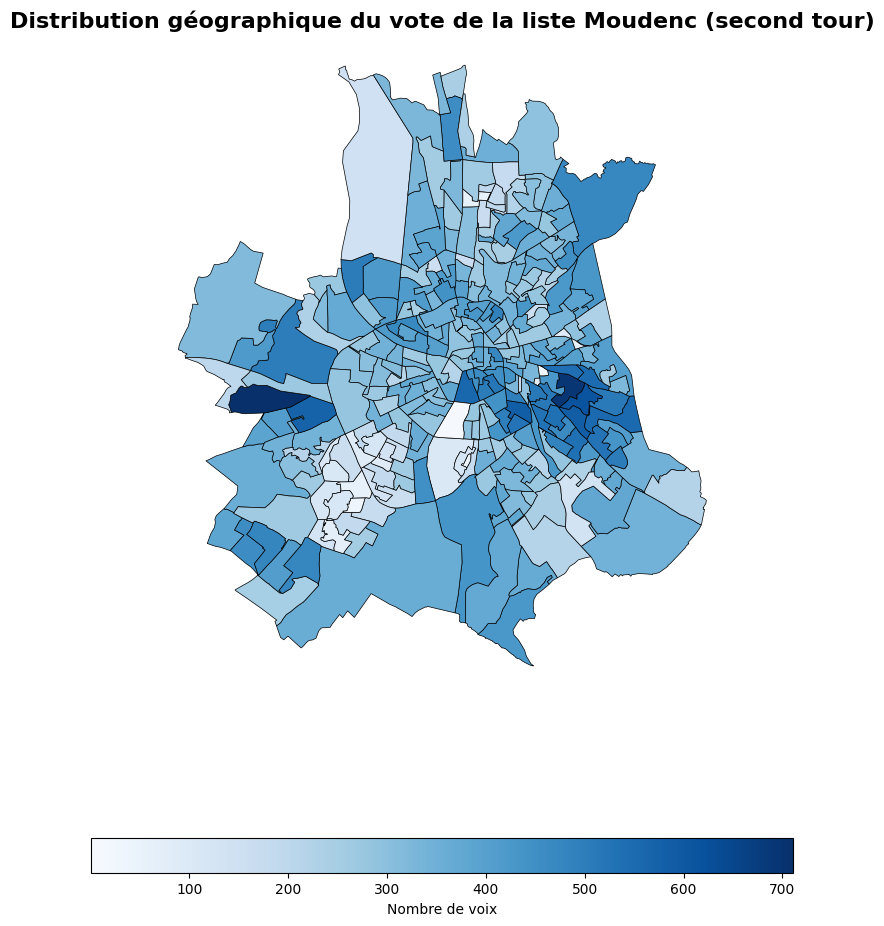

In [33]:
#| echo: false
#| warning: false
#| fig-cap: "Résultat de la liste de Moudenc au second tour"
#| fig-align: "center"
#| label: fig-map_Moudenc_second
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Moudenc_Voix_second_tour', 
    categorical=False, 
    legend=True, 
    cmap='Blues', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Moudenc (second tour)", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Moudenc_Voix_map_deuxieme_tour.png', transparent=True)

plt.show()

Les scores de la liste de la fusion au second tour figure @fig-map_gauche_unie.

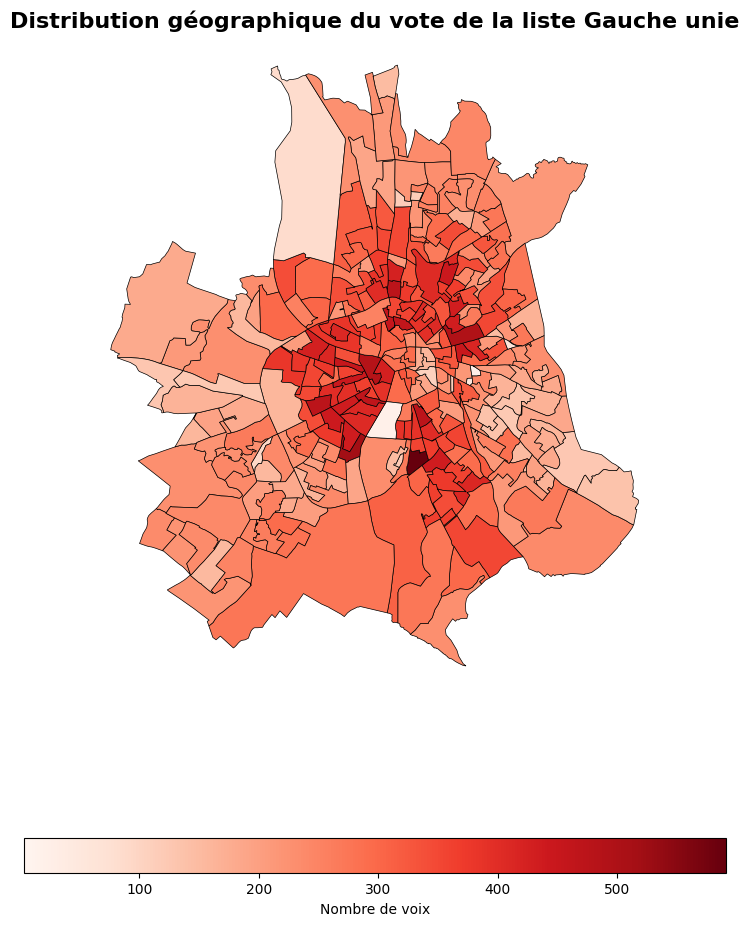

In [34]:
#| echo: false
#| warning: false
#| fig-cap: "Résultat de la liste de la gauche unie au second tour"
#| fig-align: "center"
#| label: fig-map_gauche_unie
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Piquemal_Voix_second_tour', 
    categorical=False, 
    legend=True, 
    cmap='Reds', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du vote de la liste Gauche unie", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Gauche_unie_Voix_map_deuxieme_tour.png', transparent=True)

plt.show()

Sur la figure @fig-map_delta_gauche est représentée les différents bureaux de votes dont le report de voix a été manquant (en rouge) et celui qui a ramené plus que les listes combinées au premier tour (en bleu). Donc en rouge on peut dire que c'est des électeurs de gauche anti FI (qui se sont abstenus ou ont voté blanc/nuls) et en bleu les électeurs anti Moudenc.

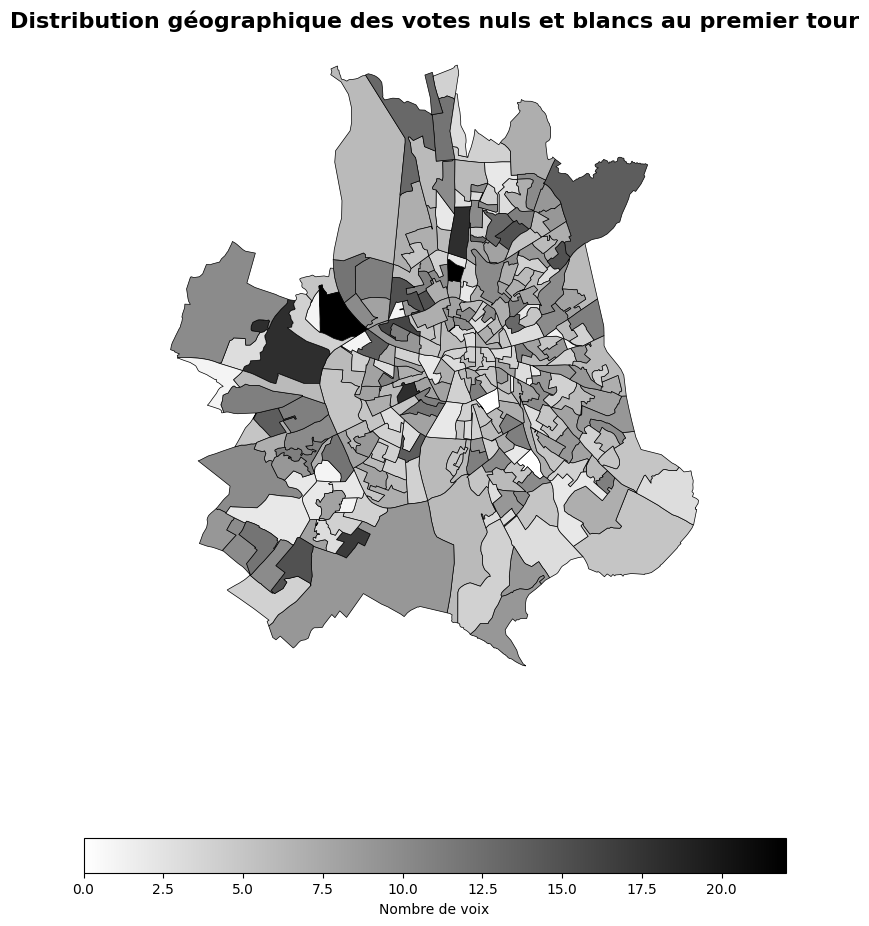

In [35]:
#| echo: false
#| warning: false
#| fig-cap: "Résultat de la liste de la gauche unie au second tour"
#| fig-align: "center"
#| label: fig-map_blc_premier
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='blc_nuls_Voix_premier_tour', 
    categorical=False, 
    legend=True, 
    cmap='binary', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique des votes nuls et blancs au premier tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Nuls_blancs_map_premier_tour.png', transparent=True)

plt.show()

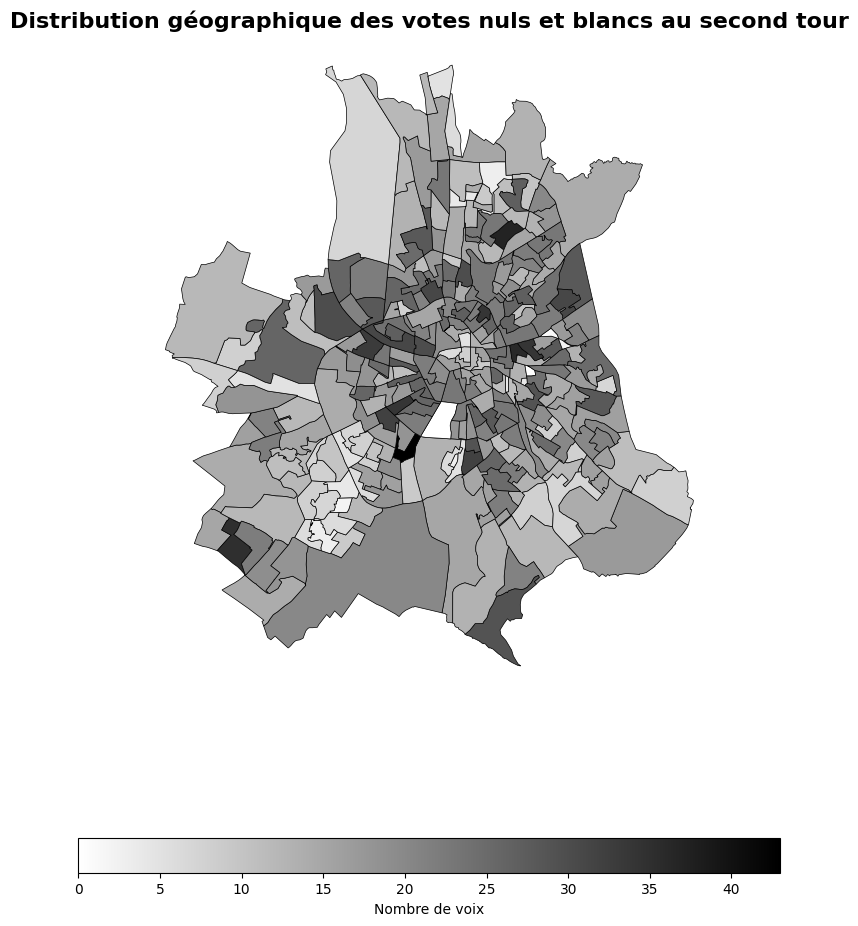

In [36]:
#| echo: false
#| warning: false
#| fig-cap: "Résultat de la liste de la gauche unie au second tour"
#| fig-align: "center"
#| label: fig-map_blc_second
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='blc_nuls_Voix_second_tour', 
    categorical=False, 
    legend=True, 
    cmap='binary', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Nombre de voix", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique des votes nuls et blancs au second tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Nuls_blancs_map_second_tour.png', transparent=True)

plt.show()

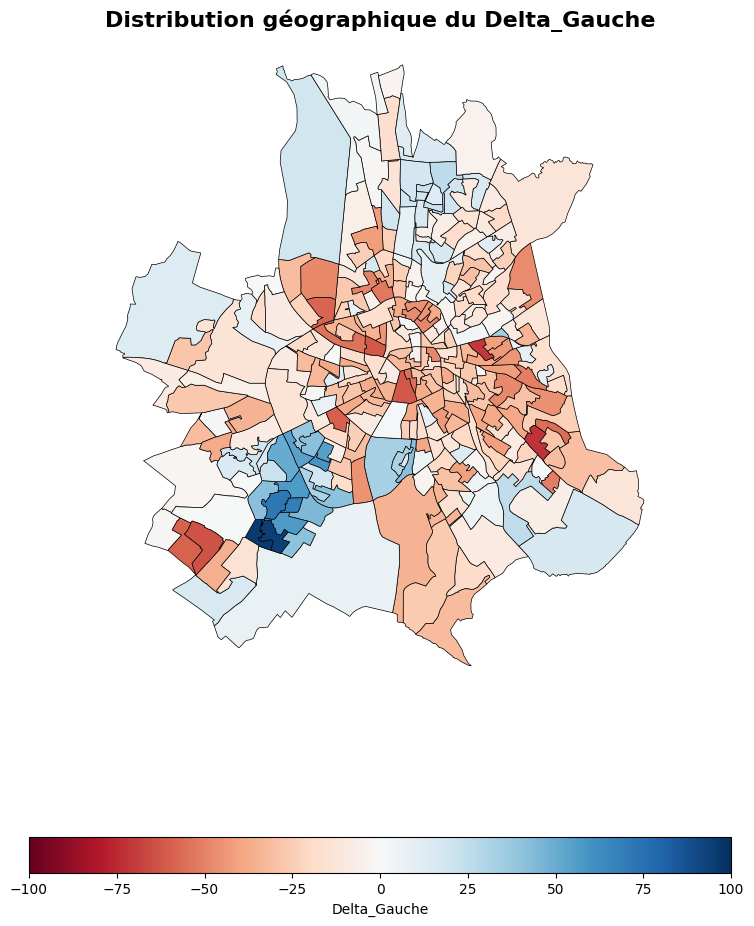

In [37]:
#| echo: false
#| warning: false
#| fig-cap: "Différence de report de voix entre premier tour et second tour"
#| fig-align: "center"
#| label: fig-map_delta_gauche
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Delta_Gauche_municipales', 
    categorical=False, vmin = -100, vmax = 100,
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Delta_Gauche", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du Delta_Gauche", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Delta_gauche_voix_map.png', transparent=True)

plt.show()

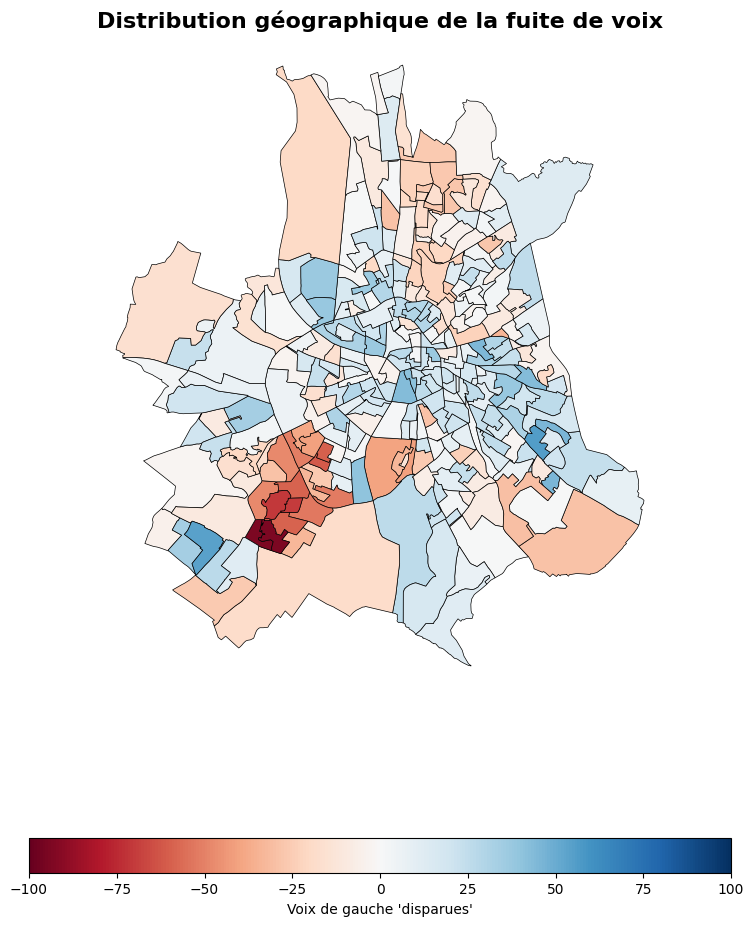

In [38]:
#| echo: false
#| warning: false
#| fig-cap: "Différence de report de voix entre premier tour et second tour"
#| fig-align: "center"
#| label: fig-map_delta_gauche
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data['fuite_de_voix'] = - final_data['Delta_Gauche_municipales'] - final_data['Delta_blc_nuls']

final_data['report_gauche_a_moudenc'] = final_data['fuite_de_voix'] + final_data['Delta_Abstention'] 

final_data.plot(
    column='fuite_de_voix', vmin = -100,vmax = 100,
    categorical=False, 
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Voix de gauche 'disparues'", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique de la fuite de voix", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/fuite_de_voix_map.png', transparent=True)

plt.show()

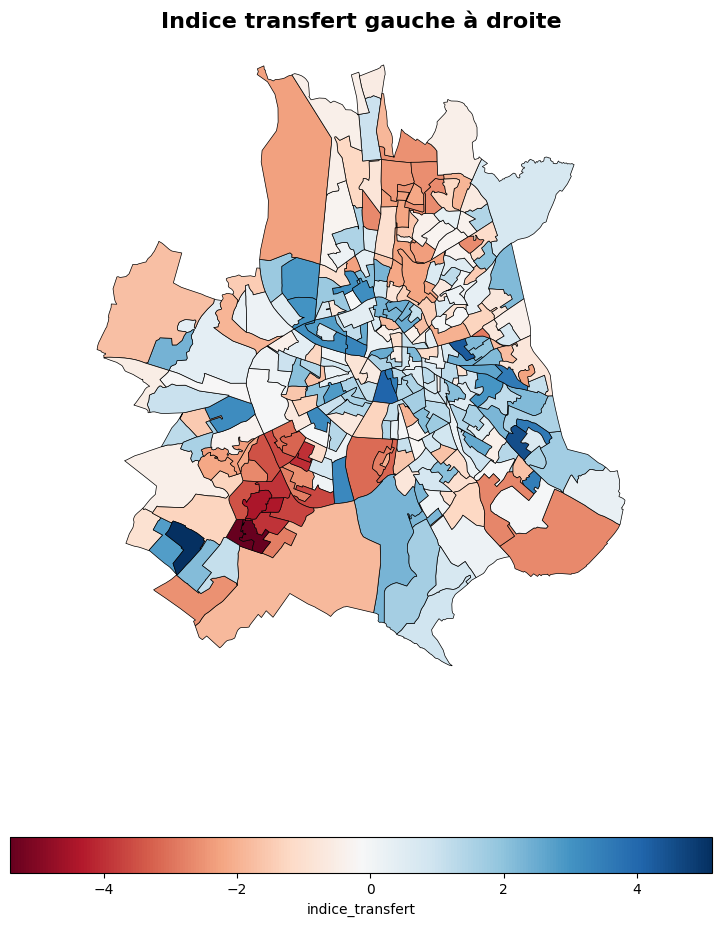

In [44]:
#| echo: false
#| warning: false
#| fig-cap: "Différence de report de voix entre premier tour et second tour"
#| fig-align: "center"
#| label: fig-map_delta_gauche
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

moy_fuite_gauche = final_data['fuite_de_voix'].mean()

ecart_type_gauche = final_data['fuite_de_voix'].std()

final_data['Z_fuite_gauche'] = (final_data['fuite_de_voix'] - moy_fuite_gauche) / ecart_type_gauche

moy_gain_droite = final_data['report_vivre_mieux_a_moudenc'].mean()

ecart_gain_droite = final_data['report_vivre_mieux_a_moudenc'].std()

final_data['Z_gain_droite'] = (final_data['report_vivre_mieux_a_moudenc'] - moy_gain_droite) / ecart_gain_droite

final_data['indice_transfert'] = final_data['Z_fuite_gauche'] + final_data['Z_gain_droite']

final_data.plot(
    column='indice_transfert',
    categorical=False, 
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "indice_transfert", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Indice transfert gauche à droite", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/indice_transfert_map.png', transparent=True)

plt.show()

Sur la figure @fig-map_delta_abstention, on peut observer les différences d'abstention entre le premier et le second tour. Attention : un delta négatif signifie bien qu'il y a eu une participation plus importante. A comparer avec les autres map.

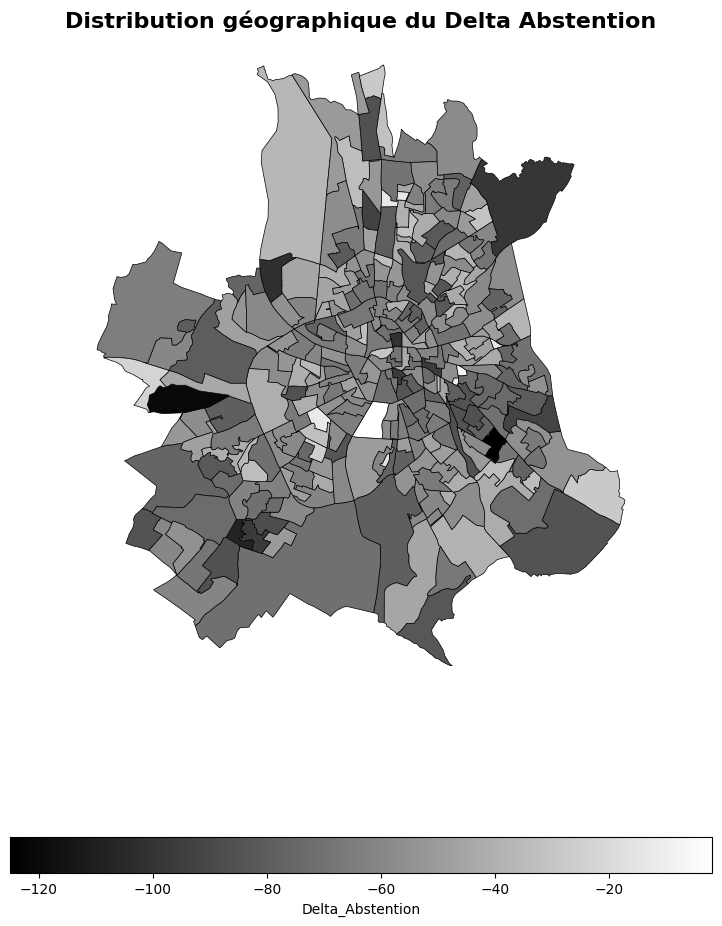

In [40]:
#| echo: false
#| warning: false
#| fig-cap: "Différence de taux d'abstention entre le premier et le second tour"
#| fig-align: "center"
#| label: fig-map_delta_abstention
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Delta_Abstention',
    categorical=False, 
    legend=True, 
    cmap='gray', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Delta_Abstention", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du Delta Abstention", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Delta_Abstention_map.png', transparent=True)

plt.show()

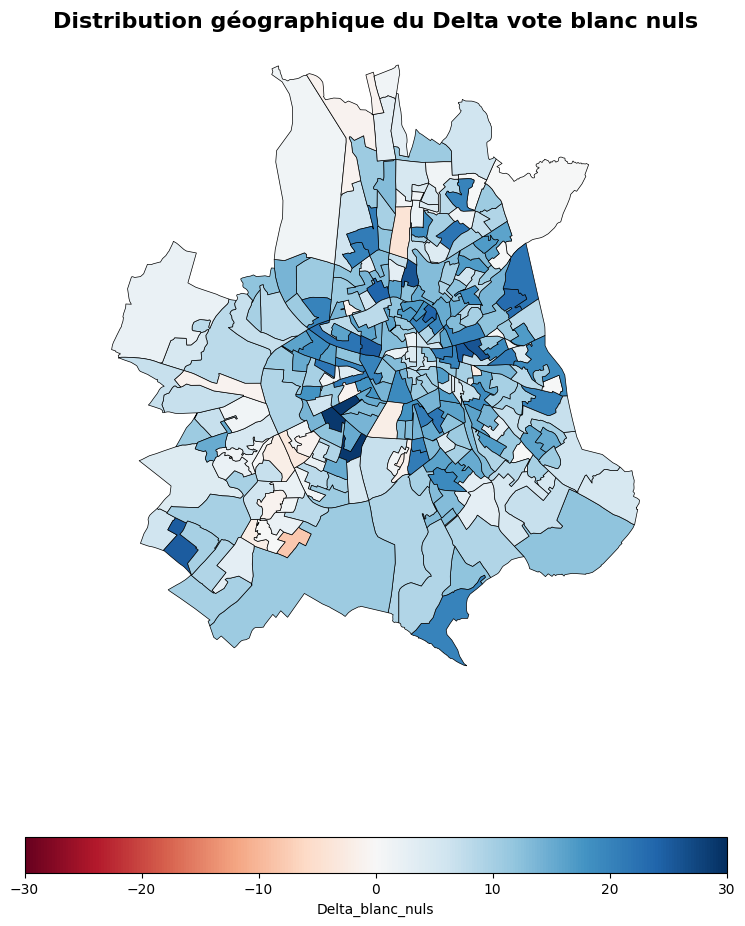

In [41]:
#| echo: false
#| warning: false
#| fig-cap: "Différence de taux d'abstention entre le premier et le second tour"
#| fig-align: "center"
#| label: fig-map_delta_abstention
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Delta_blc_nuls',
    categorical=False, vmin = -30, vmax = 30,
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Delta_blanc_nuls", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du Delta vote blanc nuls", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Delta_blc_nuls_map.png', transparent=True)

plt.show()

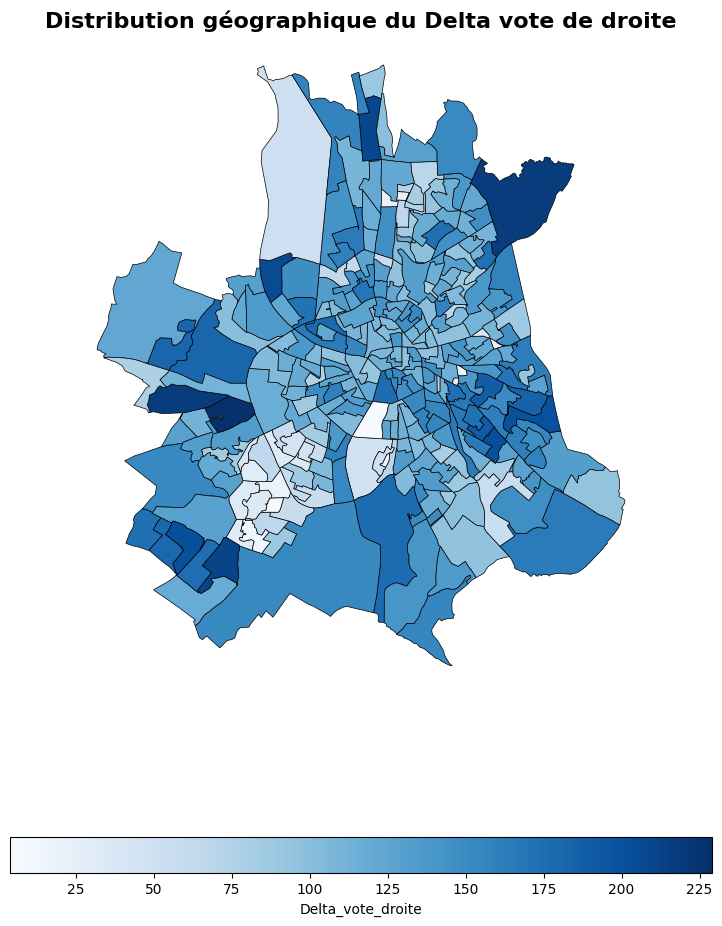

In [42]:
#| echo: false
#| warning: false
#| fig-cap: "Différence de taux d'abstention entre le premier et le second tour"
#| fig-align: "center"
#| label: fig-map_delta_abstention
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Delta_vote_droite',
    categorical=False, 
    legend=True, 
    cmap='Blues', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Delta_vote_droite", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Distribution géographique du Delta vote de droite", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Delta_droite_map.png', transparent=True)

plt.show()

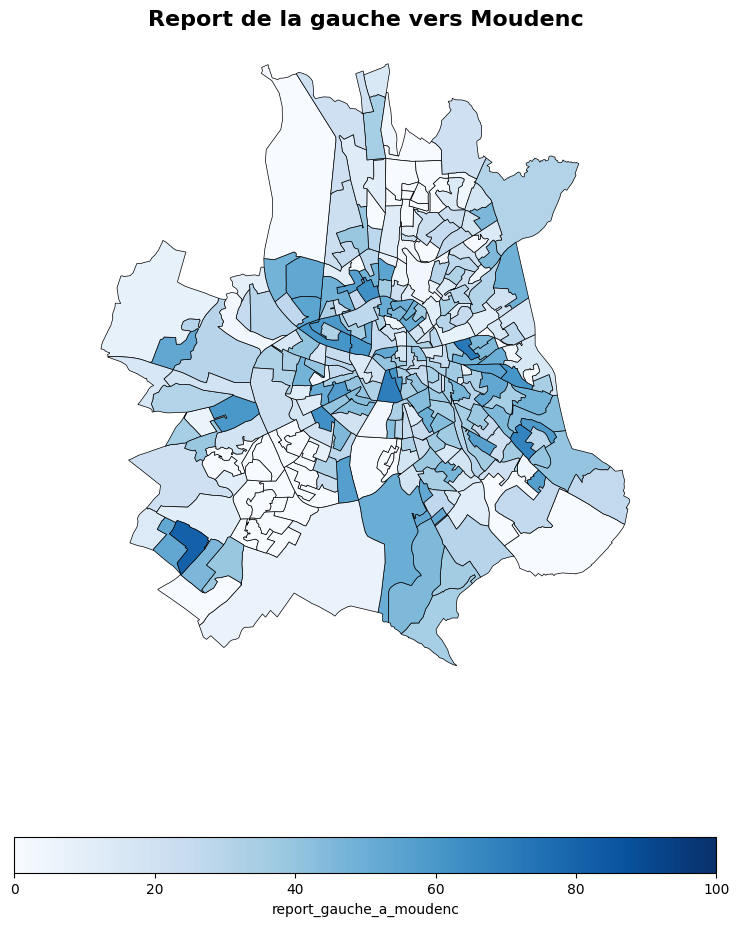

In [44]:
#| echo: false
#| warning: false
#| fig-cap: "Report de la liste vivre mieux vers Moudenc"
#| fig-align: "center"
#| label: fig-report_vivre_mieux_a_moudenc
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='report_vivre_mieux_a_moudenc',
    categorical=False, vmin = 0, vmax = 100,
    legend=True, 
    cmap='Blues', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "report_gauche_a_moudenc", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Report de la gauche vers Moudenc", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/report_gauche_a_moudenc.png', transparent=True)

plt.show()

In [48]:
print(final_data['report_vivre_mieux_a_moudenc'].sum())
print(final_data['Delta_vote_droite'].sum())
print(final_data['Briançon_Voix_premier_tour'].sum())
print(final_data['Moudenc_Voix_premier_tour'].sum())
print(final_data['Moudenc_Voix_second_tour'].sum())
print(final_data['Piquemal_Voix_premier_tour'].sum())
print(final_data['Piquemal_Voix_second_tour'].sum())
print((final_data['Piquemal_Voix_second_tour'].sum() - final_data['Piquemal_Voix_premier_tour'].sum()))


7356.0
33689.0
39245.0
58462.0
92152.0
43274.0
78925.0
35651.0


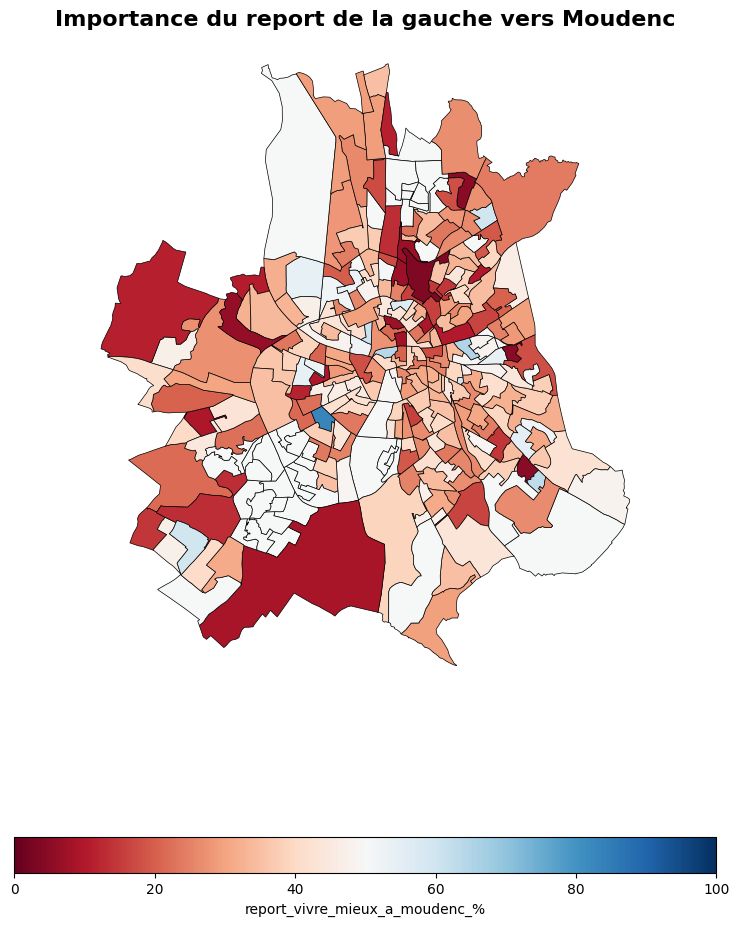

In [45]:
#| echo: false
#| warning: false
#| fig-cap: "Report de la liste vivre mieux vers Moudenc"
#| fig-align: "center"
#| label: fig-report_vivre_mieux_a_moudenc
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='report_vivre_mieux_a_moudenc_%',
    categorical=False, vmin=0, vmax = 100,
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "report_vivre_mieux_a_moudenc_%", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Importance du report de la gauche vers Moudenc", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/importance_report_gauche_a_moudenc.png', transparent=True)

plt.show()

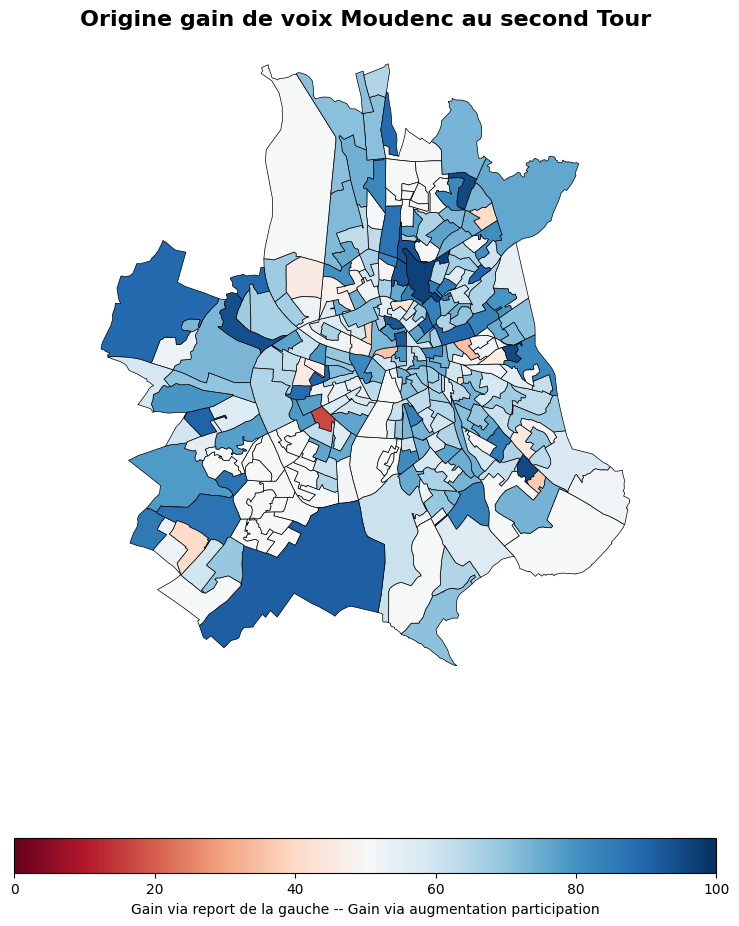

In [46]:
#| echo: false
#| warning: false
#| fig-cap: "Report de la liste vivre mieux vers Moudenc"
#| fig-align: "center"
#| label: fig-report_vivre_mieux_a_moudenc
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='gain_moudenc_participation_%',
    categorical=False, vmin=0, vmax = 100,
    legend=True, 
    cmap='RdBu', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Gain via report de la gauche -- Gain via augmentation participation", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Origine gain de voix Moudenc au second Tour", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/importance_participation_a_moudenc.png', transparent=True)

plt.show()

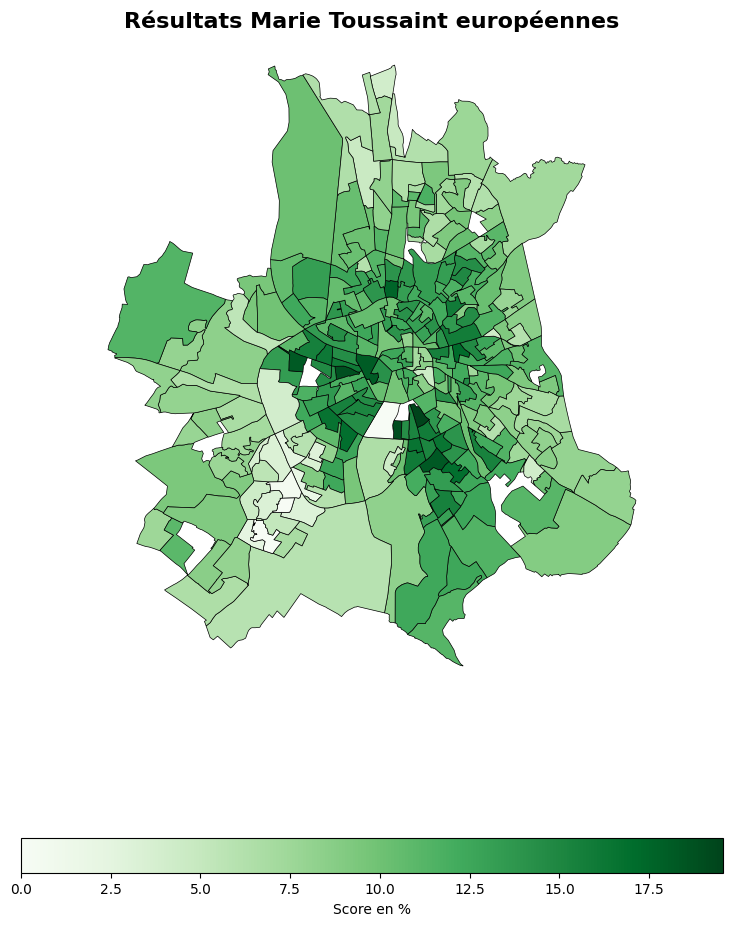

In [47]:
#| echo: false
#| warning: false
#| fig-cap: "Résultats Marie Toussaint européennes"
#| fig-align: "center"
#| label: fig-europeennees_Toussaint
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='Marie_Toussaint_Voix_europeennes_%',
    categorical=False, 
    legend=True, 
    cmap='Greens', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Score en %", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Résultats Marie Toussaint européennes", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Toussaint_map.png', transparent=True)

plt.show()

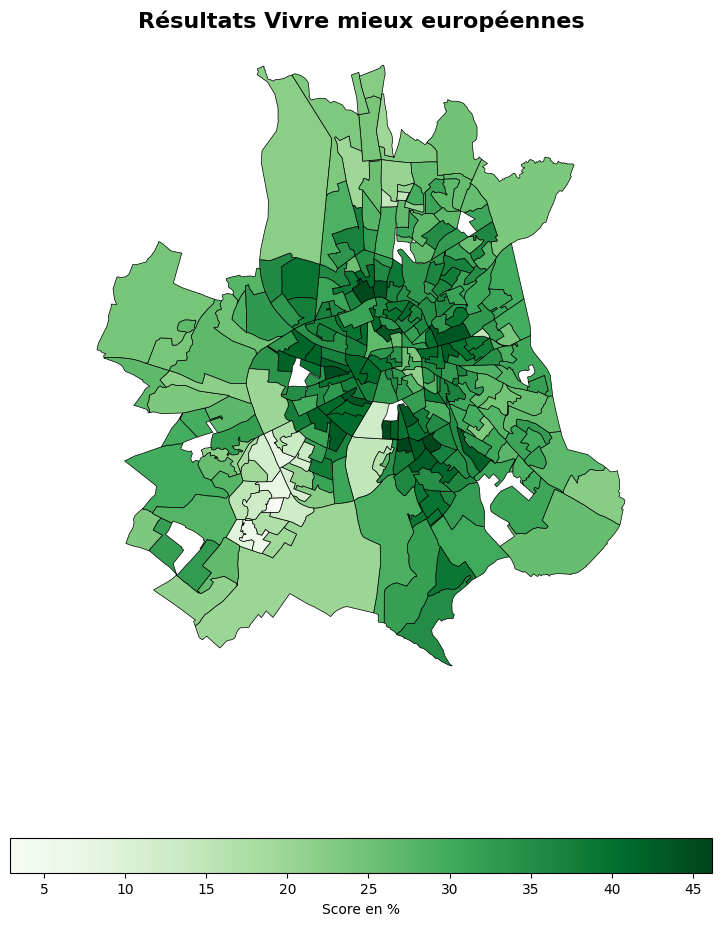

In [48]:
#| echo: false
#| warning: false
#| fig-cap: "Résultats Vivre Mieux européennes"
#| fig-align: "center"
#| label: fig-europeennees_Vivre_mieux
#| fig-pos: "H"

fig, ax = plt.subplots(figsize=(12, 10))

final_data.plot(
    column='vivre_mieux_europeennes_%',
    categorical=False, 
    legend=True, 
    cmap='Greens', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Score en %", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Résultats Vivre mieux européennes", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Vivre_mieux_europeennes_map.png', transparent=True)

plt.show()

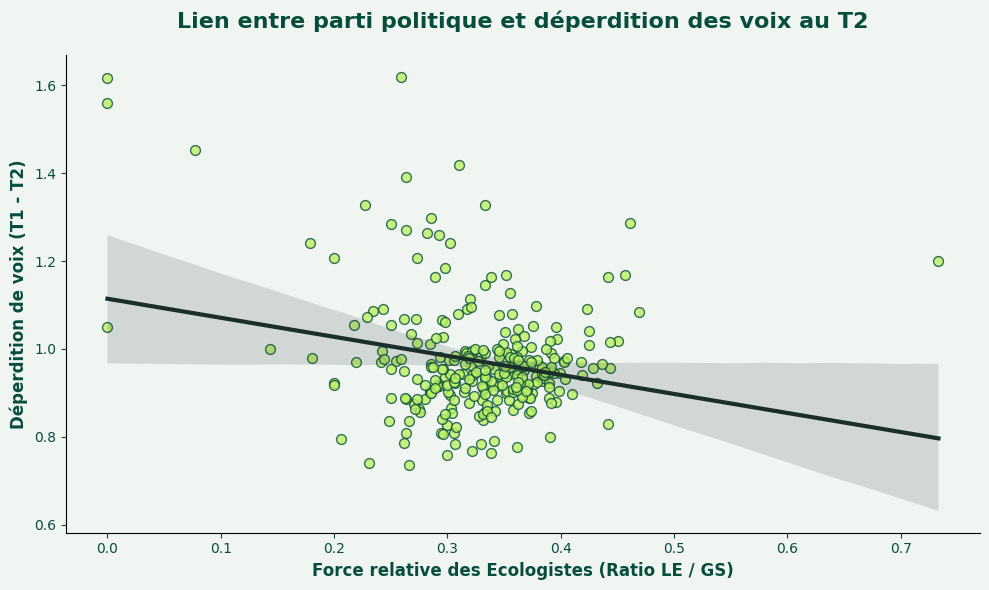

In [49]:
plt.rcParams['figure.facecolor'] = '#F1F5F2' 
plt.rcParams['axes.facecolor'] = '#F1F5F2'   
plt.rcParams['text.color'] = '#064E3B'       
plt.rcParams['axes.labelcolor'] = '#064E3B'
plt.rcParams['xtick.color'] = '#064E3B'
plt.rcParams['ytick.color'] = '#064E3B'

fig, ax = plt.subplots(figsize=(10, 6))


sns.regplot(
    data=final_data, 
    x='force_relative_des_partis', 
    y='Depertition',
    ax=ax,
    scatter_kws={'color': '#BEF264', 'edgecolor': '#064E3B', 's': 50, 'alpha': 0.8}, 
    line_kws={'color': '#1A2E2A', 'linewidth': 3} 
)

ax.set_title("Lien entre parti politique et déperdition des voix au T2", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Force relative des Ecologistes (Ratio LE / GS)", fontsize=12, fontweight='bold')
ax.set_ylabel("Déperdition de voix (T1 - T2)", fontsize=12, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.savefig('../plots/Vivre_mieux_europeennes_map.png', transparent=True)

plt.show()

In [ ]:
import statsmodels.api as sm

final_data['Fuite_Voix_T2'] = (final_data['Piquemal_Voix_premier_tour'] + final_data['Briançon_Voix_premier_tour']) - final_data['Piquemal_Voix_second_tour']
final_data['delta_abstention_municipales_second_tour_europeennes'] = final_data['abstentions_second_tour'] - final_data['abstentions_europeennes']
final_data['delta_abstention_municipales_premier_tour_europeennes'] = final_data['abstentions_premier_tour'] - final_data['abstentions_europeennes']

X = final_data[['Marie_Toussaint_Voix_europeennes', 'Manon_Aubry_Voix_europeennes', 'Raphaël_Glucksmann_Voix_europeennes', 'delta_abstention_municipales_second_tour_europeennes']]

X = sm.add_constant(X)

Y = final_data['Fuite_Voix_T2']

modele = sm.OLS(Y, X, missing='drop')
resultats = modele.fit()
print(resultats.summary())

                            OLS Regression Results                            
Dep. Variable:          Fuite_Voix_T2   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     165.6
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.61e-71
Time:                        21:22:34   Log-Likelihood:                -1132.0
No. Observations:                 276   AIC:                             2274.
Df Residuals:                     271   BIC:                             2292.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [91]:
from scipy.optimize import lsq_linear

colonnes_partis = [
    'Marie_Toussaint_Voix_europeennes', 
    'Manon_Aubry_Voix_europeennes', 
    'Raphaël_Glucksmann_Voix_europeennes'
]
colonne_controle = 'delta_abstention_municipales_second_tour_europeennes'
colonne_Y = 'Z_fuite_gauche'

toutes_colonnes = colonnes_partis + [colonne_controle, colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + [colonne_controle]].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) 
y = df_clean[colonne_Y].values

bornes_inferieures = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
bornes_superieures = [np.inf, np.inf, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print(f"Impact pour 100 voix Marie Toussaint (EELV) : {resultats[0] * 100:+.2f} points d'indice")
print(f"Impact pour 100 voix Manon Aubry (LFI)      : {resultats[1] * 100:+.2f} points d'indice")
print(f"Impact pour 100 voix R. Glucksmann (PS/PP)  : {resultats[2] * 100:+.2f} points d'indice")
print("-" * 50)
print(f"Coefficient Delta Abstention                : {resultats[3]:+.3f}")
print(f"Constante (Bruit de fond)                   : {resultats[4]:+.2f} points d'indice")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

Impact pour 100 voix Marie Toussaint (EELV) : +0.14 points d'indice
Impact pour 100 voix Manon Aubry (LFI)      : -1.45 points d'indice
Impact pour 100 voix R. Glucksmann (PS/PP)  : +1.35 points d'indice
--------------------------------------------------
Coefficient Delta Abstention                : -0.001
Constante (Bruit de fond)                   : -0.14 points d'indice
R² du modèle sous contraintes : 0.655


In [98]:
from scipy.optimize import lsq_linear

colonnes_partis = [
    'Marie_Toussaint_Voix_europeennes', 
    'Manon_Aubry_Voix_europeennes', 
    'Raphaël_Glucksmann_Voix_europeennes'
]
colonne_controle = 'delta_abstention_municipales_premier_tour_europeennes'
colonne_Y = 'Briançon_Voix_premier_tour'

toutes_colonnes = colonnes_partis + [colonne_controle, colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + [colonne_controle]].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) 

y = df_clean[colonne_Y].values

bornes_inferieures = [0, 0, 0, -np.inf, -np.inf]
bornes_superieures = [np.inf, np.inf, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print("--- Taux de report estimés vers la liste Briançon ---")
print(f"Base Marie Toussaint (EELV) : {resultats[0] * 100:.1f} %")
print(f"Base Manon Aubry (LFI)      : {resultats[1] * 100:.1f} %")
print(f"Base R. Glucksmann (PS/PP)  : {resultats[2] * 100:.1f} %")
print("-" * 50)
print(f"Coefficient Delta Abstention: {resultats[3]:.3f}")
print(f"Constante (Bruit de fond)   : {resultats[4]:.1f} voix")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

--- Taux de report estimés vers la liste Briançon ---
Base Marie Toussaint (EELV) : 70.9 %
Base Manon Aubry (LFI)      : 3.6 %
Base R. Glucksmann (PS/PP)  : 74.1 %
--------------------------------------------------
Coefficient Delta Abstention: 0.148
Constante (Bruit de fond)   : 11.2 voix
R² du modèle sous contraintes : 0.867


In [ ]:
from scipy.optimize import lsq_linear

colonnes_partis = [
    'Marie_Toussaint_Voix_europeennes', 
    'Manon_Aubry_Voix_europeennes', 
    'Raphaël_Glucksmann_Voix_europeennes'
]
colonne_controle = 'delta_abstention_municipales_premier_tour_europeennes'
colonne_Y = 'Piquemal_Voix_premier_tour'

toutes_colonnes = colonnes_partis + [colonne_controle, colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + [colonne_controle]].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) # X_matrice contient 5 colonnes

y = df_clean[colonne_Y].values

bornes_inferieures = [0, 0, 0, -np.inf, -np.inf]
bornes_superieures = [np.inf, np.inf, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print("--- Taux de report estimés vers la liste Piquemal ---")
print(f"Base Marie Toussaint (EELV) : {resultats[0] * 100:.1f} %")
print(f"Base Manon Aubry (LFI)      : {resultats[1] * 100:.1f} %")
print(f"Base R. Glucksmann (PS/PP)  : {resultats[2] * 100:.1f} %")
print("-" * 50)
print(f"Coefficient Delta Abstention: {resultats[3]:.3f}")
print(f"Constante (Bruit de fond)   : {resultats[4]:.1f} voix")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

--- Taux de report estimés vers la liste Piquemal ---
Base Marie Toussaint (EELV) : 115.8 %
Base Manon Aubry (LFI)      : 86.9 %
Base R. Glucksmann (PS/PP)  : 8.2 %
--------------------------------------------------
Coefficient Delta Abstention: 0.208
Constante (Bruit de fond)   : -11.6 voix
R² du modèle sous contraintes : 0.764


In [102]:
from scipy.optimize import lsq_linear

colonnes_partis = [
    'Briançon_Voix_premier_tour', 
    'Piquemal_Voix_premier_tour', 
    'Cottrel_Voix_premier_tour',
    'Moudenc_Voix_premier_tour'
]
colonnes_controles = ['Delta_blc_nuls', 'Delta_Abstention']
colonne_Y = 'Moudenc_Voix_second_tour'

toutes_colonnes = colonnes_partis + colonnes_controles + [colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + colonnes_controles].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) 

y = df_clean[colonne_Y].values

bornes_inferieures = [0, 0, 0, 0, -np.inf, -np.inf, -np.inf]
bornes_superieures = [1, 1, 1, 1, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print("--- Taux de report estimés vers la liste Moudenc au second tour---")
print(f"Base Briançon : {resultats[0] * 100:.1f} %")
print(f"Base Piquemal : {resultats[1] * 100:.1f} %")
print(f"Base Cottrel  : {resultats[2] * 100:.1f} %")
print(f"Voix Moudenc premier tour  : {resultats[3] * 100:.1f} %")
print("-" * 50)
print(f"Coefficient Delta_blc_nuls  : {resultats[4] * 100:.1f} %")
print(f"Coefficient Abstention  : {resultats[5] * 100:.1f} %")
print(f"Constante (Bruit de fond)   : {resultats[6]:.1f} voix")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

--- Taux de report estimés vers la liste Moudenc au second tour---
Base Briançon : 41.5 %
Base Piquemal : 0.0 %
Base Cottrel  : 100.0 %
Voix Moudenc premier tour  : 100.0 %
--------------------------------------------------
Coefficient Delta_blc_nuls  : -51.4 %
Coefficient Abstention  : -90.5 %
Constante (Bruit de fond)   : 5.6 voix
R² du modèle sous contraintes : 0.952


In [95]:
colonnes_partis = [
    'Briançon_Voix_premier_tour', 
    'Piquemal_Voix_premier_tour', 
    'Cottrel_Voix_premier_tour',
    'Moudenc_Voix_premier_tour'
]
colonnes_controles = ['Delta_blc_nuls', 'Delta_Abstention']
colonne_Y = 'Piquemal_Voix_second_tour'

toutes_colonnes = colonnes_partis + colonnes_controles + [colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + colonnes_controles].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) 

y = df_clean[colonne_Y].values

bornes_inferieures = [0, 0, 0, 0, -np.inf, -np.inf, -np.inf]
bornes_superieures = [1, 1, 1, 1, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print("--- Taux de report estimés vers la liste Piquemal au second tour---")
print(f"Base Briançon : {resultats[0] * 100:.1f} %")
print(f"Base Piquemal : {resultats[1] * 100:.1f} %")
print(f"Base Cottrel  : {resultats[2] * 100:.1f} %")
print(f"Voix Moudenc premier tour  : {resultats[3] * 100:.1f} %")
print("-" * 50)
print(f"Coefficient Delta_blc_nuls  : {resultats[4] * 100:.1f} %")
print(f"Coefficient Delta Abstention  : {resultats[5] * 100:.1f} %")
print(f"Constante (Bruit de fond)   : {resultats[6]:.1f} voix")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

--- Taux de report estimés vers la liste Piquemal au second tour---
Base Briançon : 70.1 %
Base Piquemal : 100.0 %
Base Cottrel  : 0.0 %
Voix Moudenc premier tour  : 0.0 %
--------------------------------------------------
Coefficient Delta_blc_nuls  : -69.9 %
Coefficient Delta Abstention  : -28.1 %
Constante (Bruit de fond)   : 19.2 voix
R² du modèle sous contraintes : 0.962


In [97]:
from scipy.optimize import lsq_linear

colonnes_partis = [
    'Marie_Toussaint_Voix_europeennes', 
    'Manon_Aubry_Voix_europeennes', 
    'Raphaël_Glucksmann_Voix_europeennes',
    'François_Xavier_Bellamy_Voix_europeennes',
    'Valérie_Hayer_Voix_europeennes',
    'Jordan_Bardella_Voix_europeennes',
    'Delta_Abstention'
]
colonne_controle = 'delta_abstention_municipales_premier_tour_europeennes'
colonne_Y = 'Moudenc_Voix_second_tour'

toutes_colonnes = colonnes_partis + [colonne_controle, colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + [colonne_controle]].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) 

y = df_clean[colonne_Y].values

bornes_inferieures = [0, 0, 0, 0, 0, 0, -np.inf, -np.inf, -np.inf]
bornes_superieures = [1, 1, 1, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print("--- Taux de report estimés vers la liste Moudenc ---")
print(f"Base Marie Toussaint (EELV) : {resultats[0] * 100:.1f} %")
print(f"Base Manon Aubry (LFI)      : {resultats[1] * 100:.1f} %")
print(f"Base R. Glucksmann (PS/PP)  : {resultats[2] * 100:.1f} %")
print(f"Base François_Xavier_Bellamy  : {resultats[3] * 100:.1f} %")
print(f"Base Valérie_Hayer  : {resultats[4] * 100:.1f} %")
print(f"Base Jordan_Bardella  : {resultats[5] * 100:.1f} %")
print(f"Abstention  : {resultats[6] * 100:.1f} %")
print("-" * 50)
print(f"Coefficient Delta Abstention: {resultats[7]:.3f}")
print(f"Constante (Bruit de fond)   : {resultats[8]:.1f} voix")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

--- Taux de report estimés vers la liste Moudenc ---
Base Marie Toussaint (EELV) : 0.0 %
Base Manon Aubry (LFI)      : 0.0 %
Base R. Glucksmann (PS/PP)  : 42.3 %
Base François_Xavier_Bellamy  : 204.5 %
Base Valérie_Hayer  : 133.3 %
Base Jordan_Bardella  : 112.9 %
Abstention  : -49.3 %
--------------------------------------------------
Coefficient Delta Abstention: 0.291
Constante (Bruit de fond)   : 9.9 voix
R² du modèle sous contraintes : 0.903


In [104]:
from scipy.optimize import lsq_linear

colonnes_partis = [
    'Marie_Toussaint_Voix_europeennes', 
    'Manon_Aubry_Voix_europeennes', 
    'Raphaël_Glucksmann_Voix_europeennes',
    'François_Xavier_Bellamy_Voix_europeennes',
    'Valérie_Hayer_Voix_europeennes',
    'Jordan_Bardella_Voix_europeennes',
    'Delta_Abstention'
]
colonne_controle = 'delta_abstention_municipales_europeennes'
colonne_Y = 'Piquemal_Voix_second_tour'

toutes_colonnes = colonnes_partis + [colonne_controle, colonne_Y]
df_clean = final_data.dropna(subset=toutes_colonnes)

X_brut = df_clean[colonnes_partis + [colonne_controle]].values

constante = np.ones((X_brut.shape[0], 1))
X_matrice = np.hstack((X_brut, constante)) 

y = df_clean[colonne_Y].values

bornes_inferieures = [0, 0, 0, 0, 0, 0, -np.inf, -np.inf, -np.inf]
bornes_superieures = [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]

modele_borne = lsq_linear(X_matrice, y, bounds=(bornes_inferieures, bornes_superieures))
resultats = modele_borne.x

print("--- Taux de report estimés vers la liste Piquemal ---")
print(f"Base Marie Toussaint (EELV) : {resultats[0] * 100:.1f} %")
print(f"Base Manon Aubry (LFI)      : {resultats[1] * 100:.1f} %")
print(f"Base R. Glucksmann (PS/PP)  : {resultats[2] * 100:.1f} %")
print(f"Base François_Xavier_Bellamy  : {resultats[3] * 100:.1f} %")
print(f"Base Valérie_Hayer  : {resultats[4] * 100:.1f} %")
print(f"Base Jordan_Bardella  : {resultats[5] * 100:.1f} %")
print(f"Abstention  : {resultats[6] * 100:.1f} %")
print("-" * 50)
print(f"Coefficient Delta Abstention: {resultats[7]:.3f}")
print(f"Constante (Bruit de fond)   : {resultats[8]:.1f} voix")

y_pred = np.dot(X_matrice, modele_borne.x)

ss_res = np.sum((y - y_pred)**2) 

ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)

print(f"R² du modèle sous contraintes : {r2:.3f}")

--- Taux de report estimés vers la liste Piquemal ---
Base Marie Toussaint (EELV) : 173.2 %
Base Manon Aubry (LFI)      : 127.4 %
Base R. Glucksmann (PS/PP)  : 48.0 %
Base François_Xavier_Bellamy  : 0.0 %
Base Valérie_Hayer  : 0.0 %
Base Jordan_Bardella  : 0.0 %
Abstention  : -15.4 %
--------------------------------------------------
Coefficient Delta Abstention: 0.381
Constante (Bruit de fond)   : 9.0 voix
R² du modèle sous contraintes : 0.853


In [406]:
X = final_data.drop(columns=final_data.filter(regex='score').columns).filter(regex='abstentions|Voix|bureau').filter(regex='_%|bureau')
X = X.dropna()

bureau_X = X['bureau_premier_tour']
X = X.drop(columns=final_data.filter(regex='bureau').columns)

display(X)

,blc_nuls_Voix_premier_tour_%,Briançon_Voix_premier_tour_%,Scalli_Voix_premier_tour_%,Adrada_Voix_premier_tour_%,Menendez_Voix_premier_tour_%,Moudenc_Voix_premier_tour_%,Leonardelli_Voix_premier_tour_%,Cottrel_Voix_premier_tour_%,Meilhac_Voix_premier_tour_%,Piquemal_Voix_premier_tour_%,...,Lorys_Elmayan_Voix_europeennes_%,Léon_Deffontaines_Voix_europeennes_%,Gaël_Coste_Meunier_Voix_europeennes_%,Jean_Marc_Governatori_Voix_europeennes_%,Hadama_Traoré_Voix_europeennes_%,Laure_Patas_d_Illiers_Voix_europeennes_%,Patrice_Grudé_Voix_europeennes_%,abstentions_premier_tour_%,abstentions_second_tour_%,abstentions_europeennes_%
0,0.653595,20.915033,0.163399,0.163399,0.326797,45.424837,2.124183,1.143791,0.326797,27.777778,...,0.0,2.988048,0.0,1.195219,0.0,0.000000,0.0,41.666667,35.099338,45.513514
1,1.075269,26.881720,0.179211,0.537634,0.000000,38.709677,3.225806,0.358423,0.716846,28.673835,...,0.0,2.439024,0.0,1.422764,0.0,0.000000,0.0,37.402886,29.300777,40.407674
2,0.795229,24.055666,0.198807,0.596421,0.000000,33.598410,3.777336,0.795229,2.186879,32.803181,...,0.0,0.877193,0.0,0.657895,0.0,0.000000,0.0,36.386449,32.581454,40.077821
3,0.572519,29.580153,0.190840,0.190840,0.000000,33.206107,2.671756,0.381679,1.908397,30.343511,...,0.0,1.271186,0.0,0.211864,0.0,0.000000,0.0,40.249433,33.673469,42.632850
4,1.090909,22.000000,0.000000,0.181818,0.545455,33.636364,2.363636,0.545455,1.636364,37.818182,...,0.0,1.939655,0.0,2.155172,0.0,0.000000,0.0,41.901776,35.041841,42.735043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,2.558140,22.093023,0.232558,0.232558,0.000000,45.813953,7.906977,0.930233,1.627907,20.930233,...,0.0,1.700155,0.0,1.236476,0.0,0.000000,0.0,43.023256,35.400517,47.284345
278,1.456311,25.000000,0.485437,1.456311,0.000000,30.825243,5.825243,1.699029,1.213592,32.524272,...,0.0,3.797468,0.0,1.265823,0.0,0.000000,0.0,42.661180,37.585734,42.755682
280,1.206897,25.000000,0.172414,0.344828,0.172414,39.482759,6.379310,2.068966,3.275862,22.586207,...,0.0,1.795332,0.0,2.333932,0.0,0.179533,0.0,45.446097,38.754647,41.753653
281,0.909091,20.909091,0.000000,1.212121,0.606061,37.272727,11.818182,0.606061,2.424242,23.939394,...,0.0,1.824818,0.0,1.459854,0.0,0.000000,0.0,54.693878,50.884354,54.664484


In [407]:
display(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

,blc_nuls_Voix_premier_tour_%,Briançon_Voix_premier_tour_%,Scalli_Voix_premier_tour_%,Adrada_Voix_premier_tour_%,Menendez_Voix_premier_tour_%,Moudenc_Voix_premier_tour_%,Leonardelli_Voix_premier_tour_%,Cottrel_Voix_premier_tour_%,Meilhac_Voix_premier_tour_%,Piquemal_Voix_premier_tour_%,...,Lorys_Elmayan_Voix_europeennes_%,Léon_Deffontaines_Voix_europeennes_%,Gaël_Coste_Meunier_Voix_europeennes_%,Jean_Marc_Governatori_Voix_europeennes_%,Hadama_Traoré_Voix_europeennes_%,Laure_Patas_d_Illiers_Voix_europeennes_%,Patrice_Grudé_Voix_europeennes_%,abstentions_premier_tour_%,abstentions_second_tour_%,abstentions_europeennes_%
0,0.653595,20.915033,0.163399,0.163399,0.326797,45.424837,2.124183,1.143791,0.326797,27.777778,...,0.0,2.988048,0.0,1.195219,0.0,0.000000,0.0,41.666667,35.099338,45.513514
1,1.075269,26.881720,0.179211,0.537634,0.000000,38.709677,3.225806,0.358423,0.716846,28.673835,...,0.0,2.439024,0.0,1.422764,0.0,0.000000,0.0,37.402886,29.300777,40.407674
2,0.795229,24.055666,0.198807,0.596421,0.000000,33.598410,3.777336,0.795229,2.186879,32.803181,...,0.0,0.877193,0.0,0.657895,0.0,0.000000,0.0,36.386449,32.581454,40.077821
3,0.572519,29.580153,0.190840,0.190840,0.000000,33.206107,2.671756,0.381679,1.908397,30.343511,...,0.0,1.271186,0.0,0.211864,0.0,0.000000,0.0,40.249433,33.673469,42.632850
4,1.090909,22.000000,0.000000,0.181818,0.545455,33.636364,2.363636,0.545455,1.636364,37.818182,...,0.0,1.939655,0.0,2.155172,0.0,0.000000,0.0,41.901776,35.041841,42.735043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,2.558140,22.093023,0.232558,0.232558,0.000000,45.813953,7.906977,0.930233,1.627907,20.930233,...,0.0,1.700155,0.0,1.236476,0.0,0.000000,0.0,43.023256,35.400517,47.284345
278,1.456311,25.000000,0.485437,1.456311,0.000000,30.825243,5.825243,1.699029,1.213592,32.524272,...,0.0,3.797468,0.0,1.265823,0.0,0.000000,0.0,42.661180,37.585734,42.755682
280,1.206897,25.000000,0.172414,0.344828,0.172414,39.482759,6.379310,2.068966,3.275862,22.586207,...,0.0,1.795332,0.0,2.333932,0.0,0.179533,0.0,45.446097,38.754647,41.753653
281,0.909091,20.909091,0.000000,1.212121,0.606061,37.272727,11.818182,0.606061,2.424242,23.939394,...,0.0,1.824818,0.0,1.459854,0.0,0.000000,0.0,54.693878,50.884354,54.664484


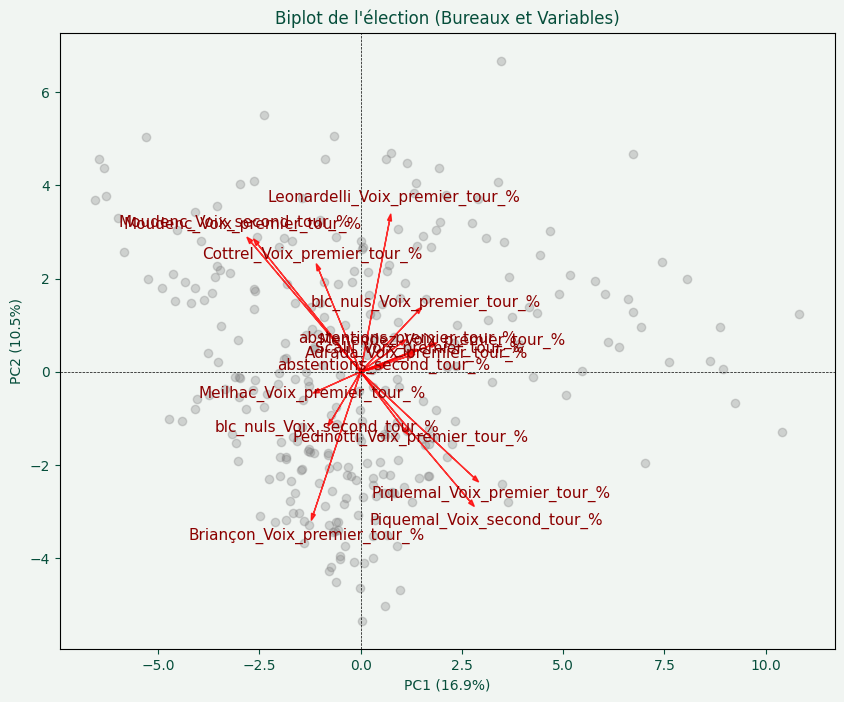

In [408]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')
plt.savefig('../plots/Biplot_premier_tour.png', transparent=True)

plt.show()

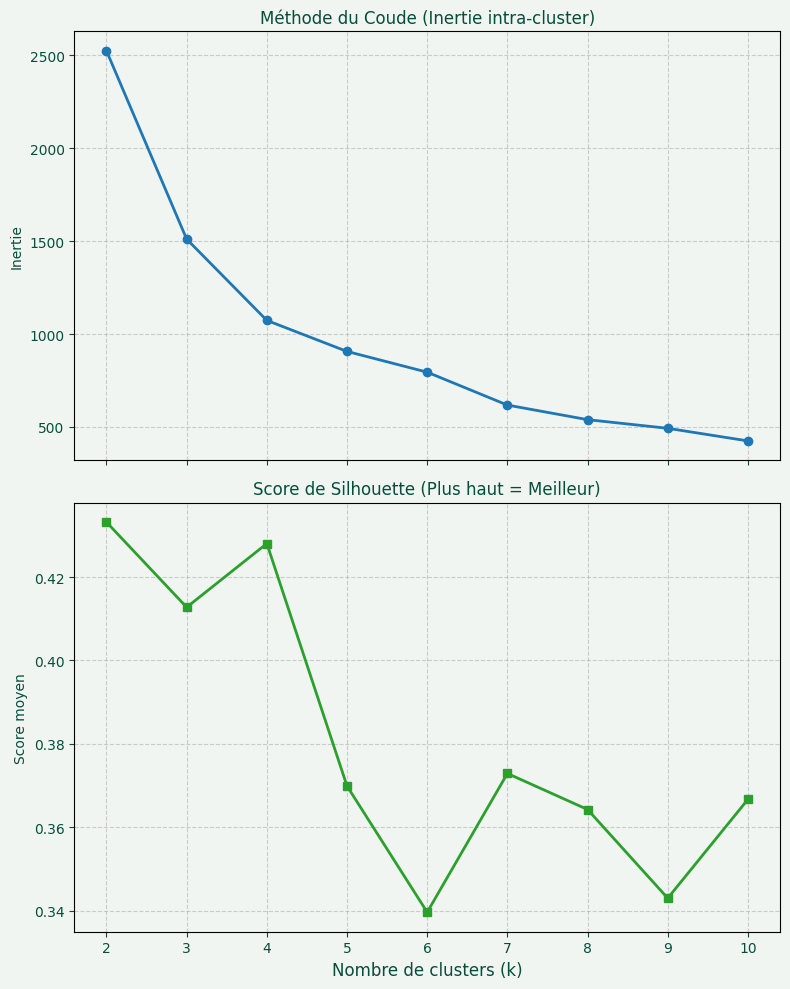

In [409]:
k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [410]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

X['Cluster_4_all_scores'] = labels_clusters.astype(str)
X['bureau_premier_tour'] = bureau_X
print("Nombre de bureaux par cluster :")
print(X['Cluster_4_all_scores'].value_counts())

final_data = pd.merge(final_data, X.filter(regex='bureau_premier_tour|Cluster_4_all_scores'), on='bureau_premier_tour', how='outer')


Nombre de bureaux par cluster :
Cluster_4_all_scores
2    112
1     75
3     57
0     32
Name: count, dtype: int64


In [411]:
profils_clusters = X.drop(columns=['bureau_premier_tour']).groupby('Cluster_4_all_scores').mean()

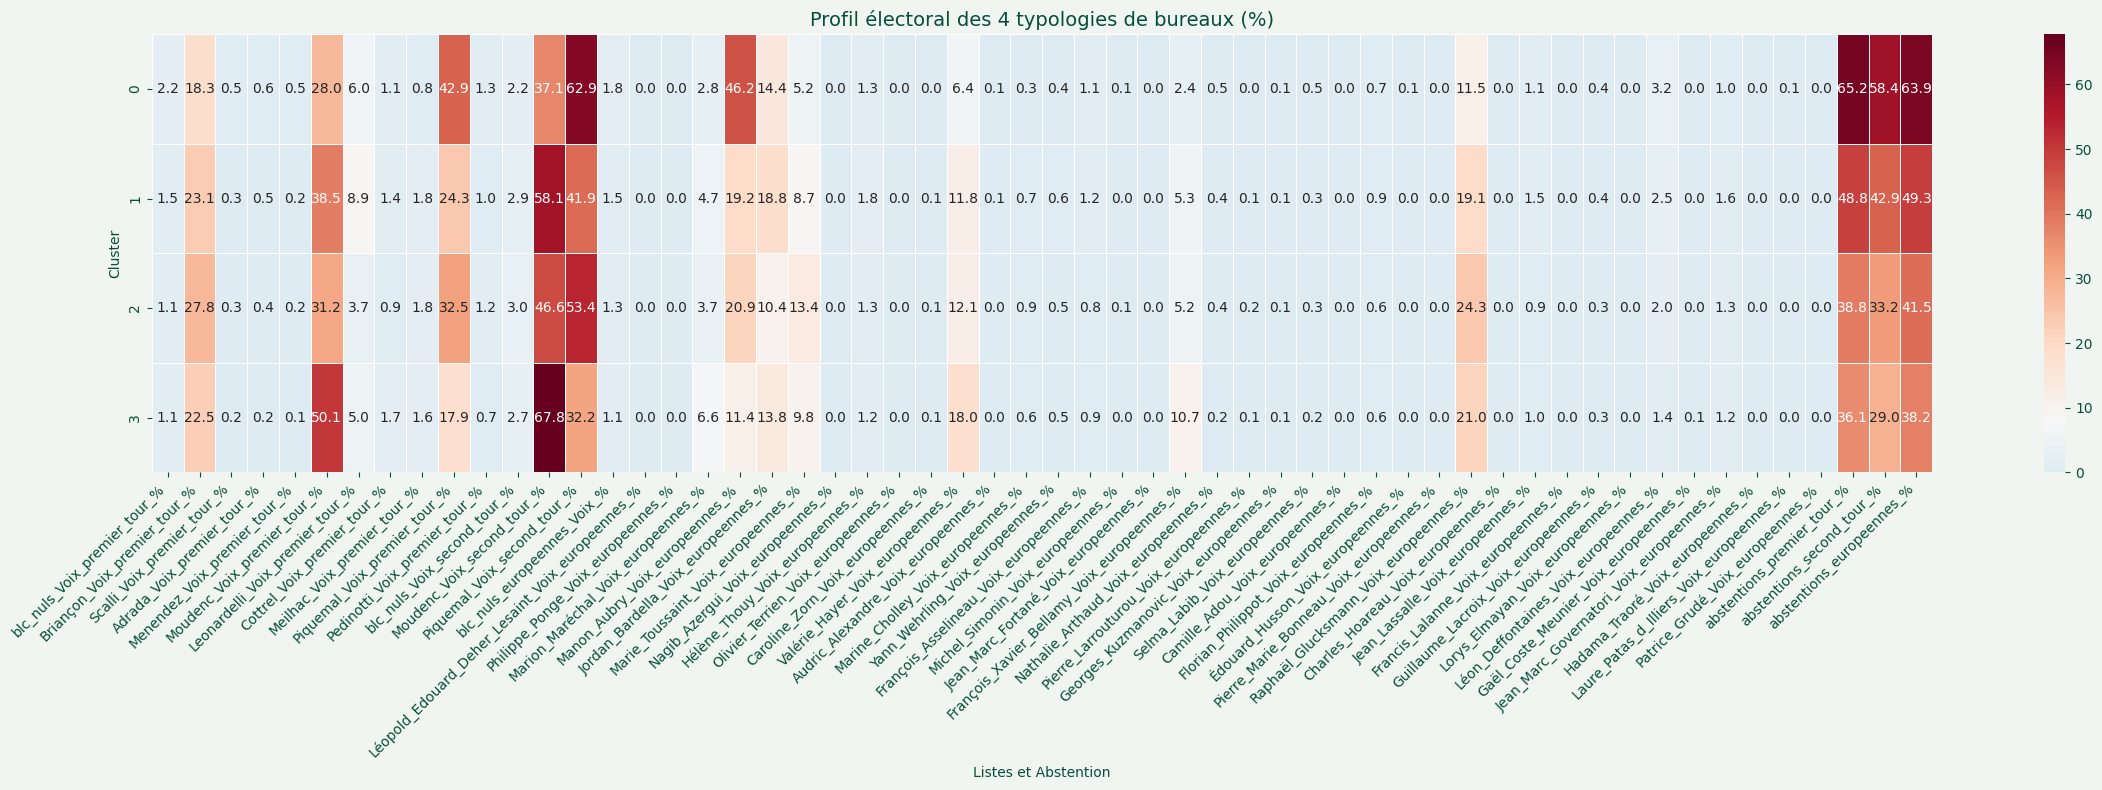

In [412]:
import seaborn as sns

plt.figure(figsize=(24, 8)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 4 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../plots/Cluster_4_all_scores.png', transparent=True)

plt.show()

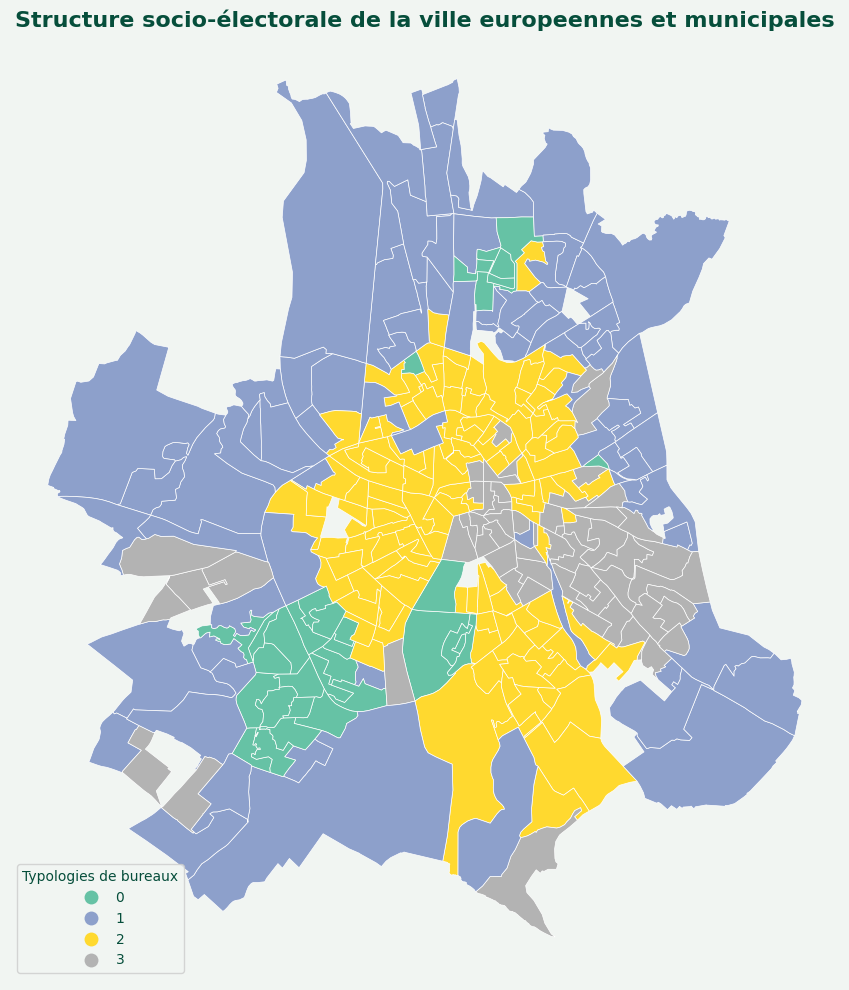

In [413]:
#| echo: false
#| warning: false
#| fig-cap: "Profil des 4 typologies de bureaux de vote All scores"
#| fig-align: "center"
#| label: fig-map_cluster4_all_time
#| fig-pos: "H"

import geopandas as gpd

fig, ax = plt.subplots(figsize=(12, 10))


final_data.plot(
    column='Cluster_4_all_scores', 
    categorical=True, 
    legend=True, 
    cmap='Set2', 
    linewidth=0.5,
    edgecolor='white', 
    ax=ax,
    legend_kwds={'title': "Typologies de bureaux", 'loc': 'lower left'}
)

ax.set_title("Structure socio-électorale de la ville europeennes et municipales", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Cluster_4_all_scores_map.png', transparent=True)

plt.show()

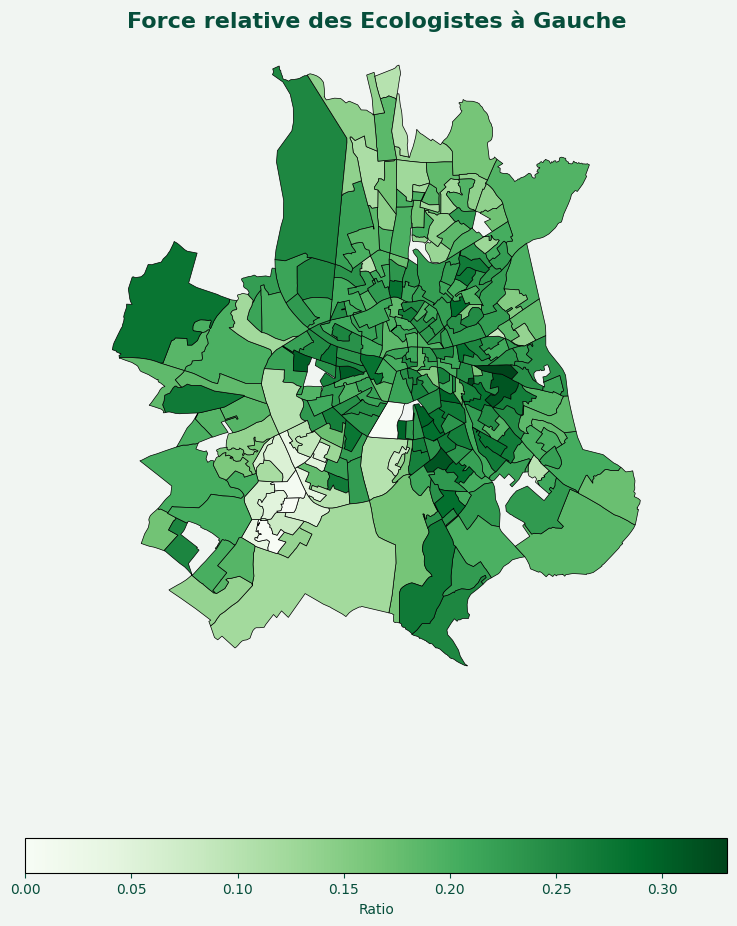

In [414]:
#| echo: false
#| warning: false
#| fig-cap: "Bastion Ecolo"
#| fig-align: "center"
#| label: fig-map_bastion_ecolo
#| fig-pos: "H"

import geopandas as gpd

fig, ax = plt.subplots(figsize=(12, 10))


final_data.plot(
    column='force_relative_des_partis_LE_PS_LFI', 
    categorical=False, 
    legend=True, 
    cmap='Greens', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Ratio", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Force relative des Ecologistes à Gauche", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Bastion_ecolo_map.png', transparent=True)

plt.show()

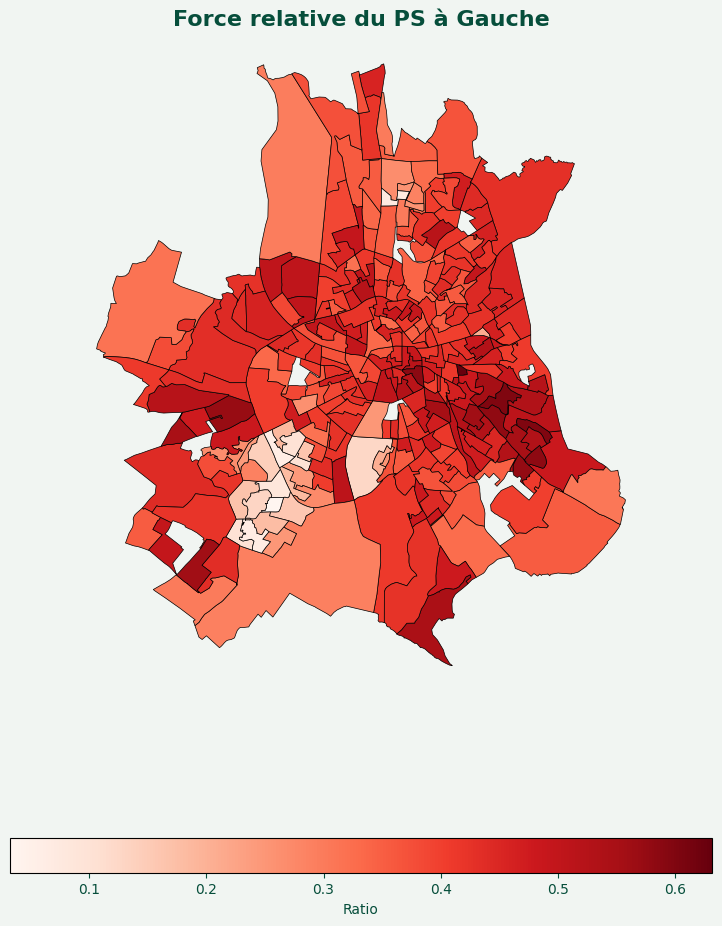

In [415]:
#| echo: false
#| warning: false
#| fig-cap: "Bastion PS"
#| fig-align: "center"
#| label: fig-map_bastion_ecolo
#| fig-pos: "H"

import geopandas as gpd

fig, ax = plt.subplots(figsize=(12, 10))


final_data.plot(
    column='force_relative_des_partis_PS_LE_LFI', 
    categorical=False, 
    legend=True, 
    cmap='Reds', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Ratio", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Force relative du PS à Gauche", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Bastion_PS_map.png', transparent=True)

plt.show()

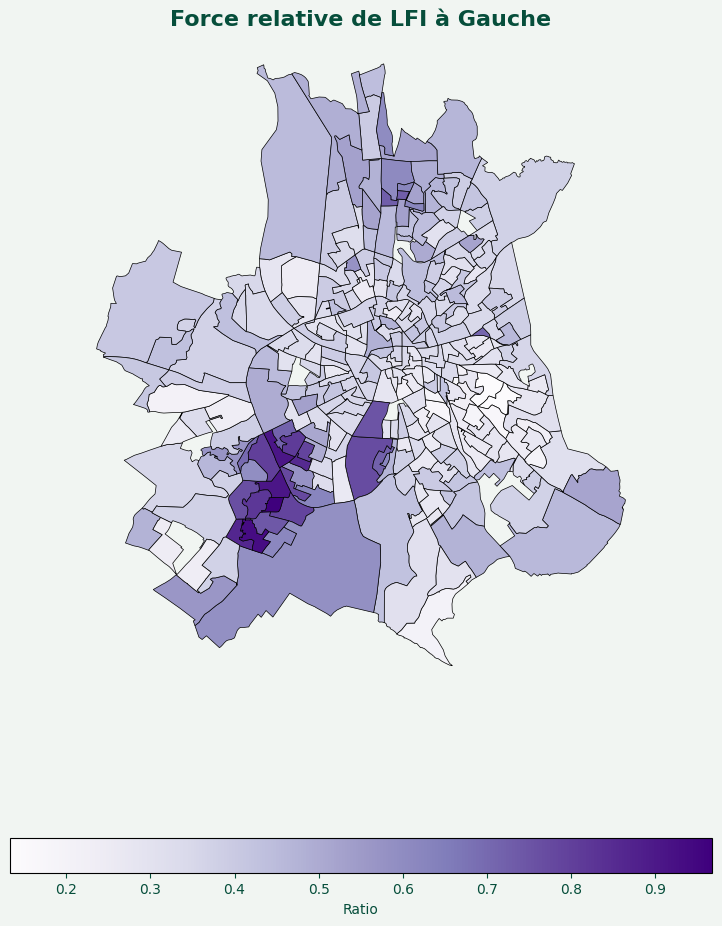

In [416]:
#| echo: false
#| warning: false
#| fig-cap: "Bastion PS"
#| fig-align: "center"
#| label: fig-map_bastion_LFI
#| fig-pos: "H"

import geopandas as gpd

fig, ax = plt.subplots(figsize=(12, 10))


final_data.plot(
    column='force_relative_des_partis_LFI_LE_PS', 
    categorical=False,  
    legend=True, 
    cmap='Purples', 
    edgecolor='black', 
    linewidth=0.5,
    ax=ax,
    legend_kwds={'label': "Ratio", 
        'orientation': "horizontal",
        'shrink': 0.6}
)

ax.set_title("Force relative de LFI à Gauche", fontsize=16, fontweight='bold')
ax.axis('off') 

plt.tight_layout()
plt.savefig('../plots/Bastion_LFI_map.png', transparent=True)

plt.show()

In [ ]:
from scipy.optimize import lsq_linear

In [417]:
final_data.to_csv('../data/results/resultats-elections-municipales-2026-analyses.csv')

### Licensing Notice
- **Code:** This work is licensed under the [GNU GPL v3](https://www.gnu.org/licenses/gpl-3.0.html).
- **Analysis & Visualizations:** The interpretive content of this notebook is licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).

*Copyright (c) 2026 Alexis Hucteau. All rights reserved.*